#########    All "our" in the following code refers to Joint Cabernet.

In [1]:
library(dplyr)
library(tidyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
hmCG <- read.csv(paste0(indir,"/03-5hmC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv"), stringsAsFactors = FALSE,check.names = F)
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Lamp5 Gaba_compartment,Pvalb Gaba_compartment,Sst Gaba_compartment,STR D1 Gaba_compartment,STR D2 Gaba_compartment,ACB-BST-FS D1 Gaba_compartment,Astro-TE NN_compartment,Oligo NN_compartment,OPC NN_compartment,Microglia NN_compartment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,


[1] 24639    60

In [ ]:
subclass_our_liu <- read.csv("../../../input/01-youth/subclass_our_liu.csv")
head(subclass_our_liu);dim(subclass_our_liu)

,subclass_our,subclass_liu
,<chr>,<chr>
1,L2/3 IT CTX Glut,L2_3_IT_CTX_Glut
2,L4/5 IT CTX Glut,L4_5_IT_CTX_Glut
3,L5 IT CTX Glut,L5_IT_CTX_Glut
4,L2/3 IT RSP Glut,L2_3_IT_RSP_Glut
5,L4 RSP-ACA Glut,L4_RSP-ACA_Glut
6,L5 ET CTX Glut,L5_ET_CTX_Glut


[1] 29  2

In [ ]:
file_list <- list.files(path = indir, 
                        pattern = "\\.bw$", full.names = FALSE)
head(file_list);length(file_list)

[1] "ABC_NN.compartment_score.100K.bw"                    
[2] "ACB-BST-FS_D1_Gaba.compartment_score.100K.bw"        
[3] "AD_Serpinb7_Glut.compartment_score.100K.bw"          
[4] "ADP-MPO_Trp73_Glut.compartment_score.100K.bw"        
[5] "AHN_Onecut3_Gaba.compartment_score.100K.bw"          
[6] "AHN-RCH-LHA_Otp_Fezf1_Glut.compartment_score.100K.bw"

[1] 273

In [5]:
subclass_liu <- sub("\\.compartment_score\\.100K\\.bw$", "", file_list) %>% data.frame()
colnames(subclass_liu) <- "subclass_liu"
head(subclass_liu);dim(subclass_liu)

,subclass_liu
,<chr>
1,ABC_NN
2,ACB-BST-FS_D1_Gaba
3,AD_Serpinb7_Glut
4,ADP-MPO_Trp73_Glut
5,AHN_Onecut3_Gaba
6,AHN-RCH-LHA_Otp_Fezf1_Glut


[1] 273   1

In [6]:
table(subclass_our_liu$subclass_liu %in% subclass_liu$subclass_liu)


TRUE 
  29 

In [ ]:
subclass_liu_bw <- paste0(indir,"/",
                          subclass_our_liu$subclass_liu,".compartment_score.100K.bw")

subclass_liu_bw

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L2_3_IT_CTX_Glut.compartment_score.100K.bw"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L4_5_IT_CTX_Glut.compartment_score.100K.bw"     
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L5_IT_CTX_Glut.compartment_score.100K.bw"       
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L2_3_IT_RSP_Glut.compartment_score.100K.bw"     
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L4_RSP-ACA_Glut.compartment_score.100K.bw"      
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L5_ET_CTX_Glut.compartment_score.100K.bw"       
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/SUB-ProS_Glut.compartment_score.100K.bw"        
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/CA1-ProS_Glut.compartment_score.100K.bw"        
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/CA3_Glut.compartment_score.100K.bw"             
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/CLA-EPd-CTX_Car3_Glut.compartment_score.100K.bw"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L5_NP_CTX_Glut.compartment_score.100K.bw"       
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L6_CT_CTX_Glut.compartment_score.100K.bw"       
[13] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/DG_Glut.compartment_score.100K.bw"              
[14] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB_Eomes_Ms4a15_Glut.compartment_score.100K.bw" 
[15] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB-in_Frmd7_Gaba.compartment_score.100K.bw"     
[16] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB-out_Frmd7_Gaba.compartment_score.100K.bw"    
[17] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB_Dopa-Gaba.compartment_score.100K.bw"         
[18] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB-STR-CTX_Inh_IMN.compartment_score.100K.bw"   
[19] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Sncg_Gaba.compartment_score.100K.bw"            
[20] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Lamp5_Gaba.compartment_score.100K.bw"           
[21] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Pvalb_Gaba.compartment_score.100K.bw"           
[22] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Sst_Gaba.compartment_score.100K.bw"             
[23] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/STR_D1_Gaba.compartment_score.100K.bw"          
[24] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/STR_D2_Gaba.compartment_score.100K.bw"          
[25] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/ACB-BST-FS_D1_Gaba.compartment_score.100K.bw"   
[26] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Astro-TE_NN.compartment_score.100K.bw"          
[27] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Oligo_NN.compartment_score.100K.bw"             
[28] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OPC_NN.compartment_score.100K.bw"             

In [8]:
library(rtracklayer)

Warning message:
“package ‘rtracklayer’ was built under R version 4.3.3”
Loading required package: GenomicRanges

Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max

In [9]:
read_bw_to_df <- function(file) {
  data <- as.data.frame(import(file))
  data$subclass <- gsub(".compartment_score.100K.bw","",basename(file))
  return(data)
}

In [10]:
all_bw_data <- lapply(subclass_liu_bw, read_bw_to_df)

combined_df <- do.call(rbind, all_bw_data)

In [11]:
head(combined_df);dim(combined_df)

,seqnames,start,end,width,strand,score,subclass
,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<chr>
1,chr1,1,100000,100000,*,0,L2_3_IT_CTX_Glut
2,chr1,100001,200000,100000,*,0,L2_3_IT_CTX_Glut
3,chr1,200001,300000,100000,*,0,L2_3_IT_CTX_Glut
4,chr1,300001,400000,100000,*,0,L2_3_IT_CTX_Glut
5,chr1,400001,500000,100000,*,0,L2_3_IT_CTX_Glut
6,chr1,500001,600000,100000,*,0,L2_3_IT_CTX_Glut


[1] 764150      7

In [12]:
table(combined_df$subclass %in% subclass_our_liu$subclass_liu)


  TRUE 
764150 

In [13]:
combined_df$subclass <- subclass_our_liu$subclass_our[match(combined_df$subclass,subclass_our_liu$subclass_liu)]

In [14]:
head(combined_df);dim(combined_df)

,seqnames,start,end,width,strand,score,subclass
,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<chr>
1,chr1,1,100000,100000,*,0,L2/3 IT CTX Glut
2,chr1,100001,200000,100000,*,0,L2/3 IT CTX Glut
3,chr1,200001,300000,100000,*,0,L2/3 IT CTX Glut
4,chr1,300001,400000,100000,*,0,L2/3 IT CTX Glut
5,chr1,400001,500000,100000,*,0,L2/3 IT CTX Glut
6,chr1,500001,600000,100000,*,0,L2/3 IT CTX Glut


[1] 764150      7

In [15]:
combined_df <- combined_df %>%
  mutate(chrom100k = paste0(seqnames, "_", (start - 1) %/% 100000))

In [16]:
head(combined_df);dim(combined_df)

,seqnames,start,end,width,strand,score,subclass,chrom100k
,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<chr>,<chr>
1,chr1,1,100000,100000,*,0,L2/3 IT CTX Glut,chr1_0
2,chr1,100001,200000,100000,*,0,L2/3 IT CTX Glut,chr1_1
3,chr1,200001,300000,100000,*,0,L2/3 IT CTX Glut,chr1_2
4,chr1,300001,400000,100000,*,0,L2/3 IT CTX Glut,chr1_3
5,chr1,400001,500000,100000,*,0,L2/3 IT CTX Glut,chr1_4
6,chr1,500001,600000,100000,*,0,L2/3 IT CTX Glut,chr1_5


[1] 764150      8

In [17]:
library(tidyr)

In [18]:
wide_df <- combined_df %>%
  select(chrom100k, score, subclass) %>%
  pivot_wider(
    names_from = subclass,
    values_from = score
  ) %>% data.frame(check.names = FALSE)

In [19]:
wide_df

chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_0,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_1,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_2,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_3,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_4,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_5,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_6,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_7,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_8,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000


In [20]:
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Lamp5 Gaba_compartment,Pvalb Gaba_compartment,Sst Gaba_compartment,STR D1 Gaba_compartment,STR D2 Gaba_compartment,ACB-BST-FS D1 Gaba_compartment,Astro-TE NN_compartment,Oligo NN_compartment,OPC NN_compartment,Microglia NN_compartment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,


[1] 24639    60

In [21]:
grep("compartment$",colnames(hmCG),value = T)

[1] "L2/3 IT CTX Glut_compartment"      "L4/5 IT CTX Glut_compartment"     
 [3] "L5 IT CTX Glut_compartment"        "L2/3 IT RSP Glut_compartment"     
 [5] "L4 RSP-ACA Glut_compartment"       "L5 ET CTX Glut_compartment"       
 [7] "SUB-ProS Glut_compartment"         "CA1-ProS Glut_compartment"        
 [9] "CA3 Glut_compartment"              "CLA-EPd-CTX Car3 Glut_compartment"
[11] "L5 NP CTX Glut_compartment"        "L6 CT CTX Glut_compartment"       
[13] "DG Glut_compartment"               "OB Eomes Ms4a15 Glut_compartment" 
[15] "OB-in Frmd7 Gaba_compartment"      "OB-out Frmd7 Gaba_compartment"    
[17] "OB Dopa-Gaba_compartment"          "OB-STR-CTX Inh IMN_compartment"   
[19] "Sncg Gaba_compartment"             "Lamp5 Gaba_compartment"           
[21] "Pvalb Gaba_compartment"            "Sst Gaba_compartment"             
[23] "STR D1 Gaba_compartment"           "STR D2 Gaba_compartment"          
[25] "ACB-BST-FS D1 Gaba_compartment"    "Astro-TE NN_compartment"          
[27] "Oligo NN_compartment"              "OPC NN_compartment"               
[29] "Microglia NN_compartment"

In [22]:
hmCG <- hmCG %>% dplyr::select(-c(grep("compartment$",colnames(hmCG),value = T),"OEC NN"))

In [23]:
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


[1] 24639    30

In [24]:
table(hmCG$chrom100k %in% wide_df$chrom100k)
table(wide_df$chrom100k %in% hmCG$chrom100k)


 TRUE 
24639 


FALSE  TRUE 
 1711 24639 

In [25]:
wide_df_filter <- wide_df[wide_df$chrom100k %in% hmCG$chrom100k,]

In [26]:
head(wide_df_filter);dim(wide_df_filter)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,chr1_1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,chr1_2,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,chr1_3,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,chr1_4,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,chr1_5,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


[1] 24639    30

In [27]:
hmCG <- hmCG[hmCG$chrom100k %in% wide_df$chrom100k,]
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


[1] 24639    30

In [28]:
merged_df <- merge(wide_df_filter, hmCG, by = "chrom100k", suffixes = c("_3C", "_hmCG"))

In [29]:
head(merged_df);dim(merged_df)

,chrom100k,L2/3 IT CTX Glut_3C,L4/5 IT CTX Glut_3C,L5 IT CTX Glut_3C,L2/3 IT RSP Glut_3C,L4 RSP-ACA Glut_3C,L5 ET CTX Glut_3C,SUB-ProS Glut_3C,CA1-ProS Glut_3C,CA3 Glut_3C,⋯,Lamp5 Gaba_hmCG,Pvalb Gaba_hmCG,Sst Gaba_hmCG,STR D1 Gaba_hmCG,STR D2 Gaba_hmCG,ACB-BST-FS D1 Gaba_hmCG,Astro-TE NN_hmCG,Oligo NN_hmCG,OPC NN_hmCG,Microglia NN_hmCG
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,chr1_1,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,chr1_10,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,chr1_100,-3.553936,0.7758843,2.683697,-0.2897587,0.4430414,5.251019,1.909102,-0.9107423,-1.757029,⋯,0.2804104,0.3160927,0.3165437,0.2303406,0.1725246,0.2730391,0.15363476,0.12683283,0.06466293,0.04577177
5,chr1_1000,-19.238665,-19.4752712,-14.370521,-19.2338257,-4.7738547,-6.669826,-1.779361,-14.4482918,-13.579443,⋯,0.2657973,0.3520153,0.2973053,0.2752037,0.1825948,0.3051242,0.07740205,0.05351853,0.04083059,0.02666875
6,chr1_1001,-19.035269,-19.7375679,-14.601047,-19.3711510,-4.7195754,-7.194997,-2.375739,-14.7525692,-13.175953,⋯,0.2428491,0.3230675,0.2920189,0.2516312,0.1321175,0.2957968,0.05445714,0.04566925,0.03814502,0.01980660


[1] 24639    59

In [30]:
subclass_columns <- colnames(wide_df_filter)[-1]
subclass_columns

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "L2/3 IT RSP Glut"      "L4 RSP-ACA Glut"       "L5 ET CTX Glut"       
 [7] "SUB-ProS Glut"         "CA1-ProS Glut"         "CA3 Glut"             
[10] "CLA-EPd-CTX Car3 Glut" "L5 NP CTX Glut"        "L6 CT CTX Glut"       
[13] "DG Glut"               "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"     
[16] "OB-out Frmd7 Gaba"     "OB Dopa-Gaba"          "OB-STR-CTX Inh IMN"   
[19] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[22] "Sst Gaba"              "STR D1 Gaba"           "STR D2 Gaba"          
[25] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "Oligo NN"             
[28] "OPC NN"                "Microglia NN"

In [31]:
# correlations <- numeric(length(subclass_columns))

In [32]:
# for (i in seq_along(subclass_columns)) {
#   subclass <- subclass_columns[i]
#   wide_values <- merged_df[[paste0(subclass, "_3C")]]
#   hmCG_values <- merged_df[[paste0(subclass, "_hmCG")]]
#   correlations[i] <- cor(wide_values, hmCG_values, method = "pearson", use = "complete.obs")
# }

In [33]:
# correlation_df <- data.frame(subclass = subclass_columns, correlation = correlations)

In [34]:
correlation_df <- data.frame(
  subclass = character(),
  correlation = numeric(),
  p_value = numeric(),
  stringsAsFactors = FALSE
)

In [35]:
for (i in seq_along(subclass_columns)) {
  subclass <- subclass_columns[i]
  wide_values <- merged_df[[paste0(subclass, "_3C")]]
  hmCG_values <- merged_df[[paste0(subclass, "_hmCG")]]

  test_result <- cor.test(wide_values, hmCG_values, method = "pearson", use = "complete.obs")

  correlation_df <- rbind(correlation_df, data.frame(
    subclass = subclass,
    correlation = test_result$estimate,
    p_value = test_result$p.value
  ))
}

In [36]:
correlation_df

,subclass,correlation,p_value
,<chr>,<dbl>,<dbl>
cor,L2/3 IT CTX Glut,0.2224626,3.278419e-267
cor1,L4/5 IT CTX Glut,0.2547224,0.000000e+00
cor2,L5 IT CTX Glut,0.2736434,0.000000e+00
cor3,L2/3 IT RSP Glut,0.2642071,0.000000e+00
cor4,L4 RSP-ACA Glut,0.2194816,6.042777e-260
cor5,L5 ET CTX Glut,0.2271405,9.108250e-279
cor6,SUB-ProS Glut,0.2415762,3.860511e-316
cor7,CA1-ProS Glut,0.2370252,4.336952e-304
cor8,CA3 Glut,0.3139932,0.000000e+00


In [37]:
correlation_df

,subclass,correlation,p_value
,<chr>,<dbl>,<dbl>
cor,L2/3 IT CTX Glut,0.2224626,3.278419e-267
cor1,L4/5 IT CTX Glut,0.2547224,0.000000e+00
cor2,L5 IT CTX Glut,0.2736434,0.000000e+00
cor3,L2/3 IT RSP Glut,0.2642071,0.000000e+00
cor4,L4 RSP-ACA Glut,0.2194816,6.042777e-260
cor5,L5 ET CTX Glut,0.2271405,9.108250e-279
cor6,SUB-ProS Glut,0.2415762,3.860511e-316
cor7,CA1-ProS Glut,0.2370252,4.336952e-304
cor8,CA3 Glut,0.3139932,0.000000e+00


In [ ]:
calculate_correlation <- function(data_path) {

  read_and_fix <- function(file_path) {
    df <- read.csv(file_path, stringsAsFactors = FALSE, check.names = FALSE)
    if (colnames(df)[1] == "") {
      colnames(df)[1] <- "chrom100k"
      message("The first column name in the file '", file_path, "' was empty and has been replaced with 'chrom100k'.")
    }
    return(df)
  }

  data <- read_and_fix(data_path)
  print(dim(data))

  data <- data %>%
    dplyr::select(-c(grep("compartment$", colnames(data), value = TRUE), "OEC NN"))

  subclass_our_liu <- read.csv("../../../input/01-youth/subclass_our_liu.csv")

  bw_dir <- indir

  file_list <- list.files(path = bw_dir, pattern = "\\.bw$", full.names = FALSE)
  subclass_liu <- sub("\\.compartment_score\\.100K\\.bw$", "", file_list) %>% data.frame()
  colnames(subclass_liu) <- "subclass_liu"

  subclass_liu_bw <- paste0(bw_dir, "/", subclass_our_liu$subclass_liu, ".compartment_score.100K.bw")

  read_bw_to_df <- function(file) {
    data <- as.data.frame(import(file))
    data$subclass <- gsub(".compartment_score.100K.bw", "", basename(file))
    return(data)
  }

  all_bw_data <- lapply(subclass_liu_bw, read_bw_to_df)
  combined_df <- do.call(rbind, all_bw_data)

  combined_df$subclass <- subclass_our_liu$subclass_our[match(combined_df$subclass, subclass_our_liu$subclass_liu)]

  combined_df <- combined_df %>%
    mutate(chrom100k = paste0(seqnames, "_", (start - 1) %/% 100000))

  wide_df <- combined_df %>%
    select(chrom100k, score, subclass) %>%
    pivot_wider(
      names_from = subclass,
      values_from = score
    ) %>%
    data.frame(check.names = FALSE)

  print(table(data$chrom100k %in% wide_df$chrom100k))
  print(table(wide_df$chrom100k %in% data$chrom100k))

  wide_df_filter <- wide_df[wide_df$chrom100k %in% data$chrom100k, ]
  data <- data[data$chrom100k %in% wide_df$chrom100k, ]

  merged_df <- merge(wide_df_filter, data, by = "chrom100k", suffixes = c("_3C", "_data"))

  subclass_columns <- colnames(wide_df_filter)[-1]

  correlations <- numeric(length(subclass_columns))
  p_values <- numeric(length(subclass_columns))

  for (i in seq_along(subclass_columns)) {
    subclass <- subclass_columns[i]
    wide_values <- merged_df[[paste0(subclass, "_3C")]]
    data_values <- merged_df[[paste0(subclass, "_data")]]
    cor_test_result <- cor.test(wide_values, data_values, method = "pearson", use = "complete.obs")
    correlations[i] <- cor_test_result$estimate
    p_values[i] <- cor_test_result$p.value 
  }

  correlation_df <- data.frame(
  subclass = subclass_columns, 
  correlation = correlations,
  p_value = p_values)

  return(correlation_df)
}

In [ ]:
cor_5hmCG <- calculate_correlation(paste0(indir,"/03-5hmC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv"))
cor_5hmCG

[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation,p_value
<chr>,<dbl>,<dbl>
L2/3 IT CTX Glut,0.2224626,3.278419e-267
L4/5 IT CTX Glut,0.2547224,0.000000e+00
L5 IT CTX Glut,0.2736434,0.000000e+00
L2/3 IT RSP Glut,0.2642071,0.000000e+00
L4 RSP-ACA Glut,0.2194816,6.042777e-260
L5 ET CTX Glut,0.2271405,9.108250e-279
SUB-ProS Glut,0.2415762,3.860511e-316
CA1-ProS Glut,0.2370252,4.336952e-304
CA3 Glut,0.3139932,0.000000e+00


In [ ]:
cor_5hmCG_5mCG <- calculate_correlation(paste0(indir,"/03-5mC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv"))
cor_5hmCG_5mCG

[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation,p_value
<chr>,<dbl>,<dbl>
L2/3 IT CTX Glut,-0.3827045,0.000000e+00
L4/5 IT CTX Glut,-0.3788386,0.000000e+00
L5 IT CTX Glut,-0.3887755,0.000000e+00
L2/3 IT RSP Glut,-0.4345233,0.000000e+00
L4 RSP-ACA Glut,-0.4057322,0.000000e+00
L5 ET CTX Glut,-0.3884104,0.000000e+00
SUB-ProS Glut,-0.3963384,0.000000e+00
CA1-ProS Glut,-0.4279029,0.000000e+00
CA3 Glut,-0.4130494,0.000000e+00


In [41]:
# cor_5hmCG_5mCG <- calculate_correlation("../output/03-5mC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv")
# cor_5hmCG_5mCG

In [ ]:
cor_5mCG <- calculate_correlation(paste0(indir,"/03-true5mC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv"))
cor_5mCG

The first column name in the file '../output/03-true5mC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv' was empty and has been replaced with 'chrom100k'.



[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation,p_value
<chr>,<dbl>,<dbl>
L2/3 IT CTX Glut,-0.40628688,0.0000000
L4/5 IT CTX Glut,-0.41799372,0.0000000
L5 IT CTX Glut,-0.43582389,0.0000000
L2/3 IT RSP Glut,-0.46315359,0.0000000
L4 RSP-ACA Glut,-0.43120663,0.0000000
L5 ET CTX Glut,-0.41321924,0.0000000
SUB-ProS Glut,-0.42369797,0.0000000
CA1-ProS Glut,-0.44174916,0.0000000
CA3 Glut,-0.46214772,0.0000000


In [38]:
# cor_5mCG <- calculate_correlation("../output/03-true5mC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv")
# cor_5mCG

The first column name in the file '../output/03-true5mC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv' was empty and has been replaced with 'chrom100k'.



[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation
<chr>,<dbl>
L2/3 IT CTX Glut,-0.40628688
L4/5 IT CTX Glut,-0.41799372
L5 IT CTX Glut,-0.43582389
L2/3 IT RSP Glut,-0.46315359
L4 RSP-ACA Glut,-0.43120663
L5 ET CTX Glut,-0.41321924
SUB-ProS Glut,-0.42369797
CA1-ProS Glut,-0.44174916
CA3 Glut,-0.46214772


In [ ]:
cor_5hmCH <- calculate_correlation(paste0(indir,"/03-5hmC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv"))
cor_5hmCH

[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation,p_value
<chr>,<dbl>,<dbl>
L2/3 IT CTX Glut,0.19826513,1.435344e-211
L4/5 IT CTX Glut,0.22055681,1.420390e-262
L5 IT CTX Glut,0.22373496,2.487031e-270
L2/3 IT RSP Glut,0.18566793,2.449768e-185
L4 RSP-ACA Glut,0.18985823,7.804565e-194
L5 ET CTX Glut,0.23768987,7.563693e-306
SUB-ProS Glut,0.16916446,9.724435e-154
CA1-ProS Glut,0.16612913,2.841355e-148
CA3 Glut,0.17234454,1.389602e-159


In [39]:
# cor_5hmCH <- calculate_correlation("../output/03-5hmC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv")
# cor_5hmCH

[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation
<chr>,<dbl>
L2/3 IT CTX Glut,0.19826513
L4/5 IT CTX Glut,0.22055681
L5 IT CTX Glut,0.22373496
L2/3 IT RSP Glut,0.18566793
L4 RSP-ACA Glut,0.18985823
L5 ET CTX Glut,0.23768987
SUB-ProS Glut,0.16916446
CA1-ProS Glut,0.16612913
CA3 Glut,0.17234454


In [ ]:
cor_5hmCH_5mCH <- calculate_correlation(paste0(indir,"/03-5mC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv"))
cor_5hmCH_5mCH

[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation,p_value
<chr>,<dbl>,<dbl>
L2/3 IT CTX Glut,0.004684658,4.677198e-01
L4/5 IT CTX Glut,0.073898368,1.845029e-30
L5 IT CTX Glut,0.022376895,5.220537e-04
L2/3 IT RSP Glut,-0.045312164,2.102573e-12
L4 RSP-ACA Glut,-0.012469663,5.324442e-02
L5 ET CTX Glut,-0.048576884,4.905352e-14
SUB-ProS Glut,-0.019683219,2.277161e-03
CA1-ProS Glut,-0.015897370,1.372127e-02
CA3 Glut,0.007395481,2.516203e-01


In [40]:
# cor_5hmCH_5mCH <- calculate_correlation("../output/03-5mC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv")
# cor_5hmCH_5mCH

[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation
<chr>,<dbl>
L2/3 IT CTX Glut,0.004684658
L4/5 IT CTX Glut,0.073898368
L5 IT CTX Glut,0.022376895
L2/3 IT RSP Glut,-0.045312164
L4 RSP-ACA Glut,-0.012469663
L5 ET CTX Glut,-0.048576884
SUB-ProS Glut,-0.019683219
CA1-ProS Glut,-0.015897370
CA3 Glut,0.007395481


In [ ]:
cor_5mCH <- calculate_correlation(paste0(indir,"/03-true5mC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv"))
cor_5mCH

The first column name in the file '../output/03-true5mC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv' was empty and has been replaced with 'chrom100k'.



[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation,p_value
<chr>,<dbl>,<dbl>
L2/3 IT CTX Glut,-0.040739022,2.653777e-10
L4/5 IT CTX Glut,0.035006245,5.694445e-08
L5 IT CTX Glut,-0.022768077,4.158111e-04
L2/3 IT RSP Glut,-0.096047105,2.339011e-50
L4 RSP-ACA Glut,-0.048420006,5.924498e-14
L5 ET CTX Glut,-0.088589110,4.474069e-43
SUB-ProS Glut,-0.078990320,1.421235e-34
CA1-ProS Glut,-0.066189111,9.468371e-25
CA3 Glut,-0.051767966,9.747003e-16


In [41]:
# cor_5mCH <- calculate_correlation("../output/03-true5mC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv")
# cor_5mCH

The first column name in the file '../output/03-true5mC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv' was empty and has been replaced with 'chrom100k'.



[1] 24639    60

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation
<chr>,<dbl>
L2/3 IT CTX Glut,-0.040739022
L4/5 IT CTX Glut,0.035006245
L5 IT CTX Glut,-0.022768077
L2/3 IT RSP Glut,-0.096047105
L4 RSP-ACA Glut,-0.048420006
L5 ET CTX Glut,-0.088589110
SUB-ProS Glut,-0.078990320
CA1-ProS Glut,-0.066189111
CA3 Glut,-0.051767966


In [46]:
library(ggplot2)

In [47]:
cor_5hmCG$Group <- "5hmCG"
cor_5hmCG_5mCG$Group <- "5hmCG+5mCG"
cor_5mCG$Group <- "5mCG"
cor_5hmCH$Group <- "5hmCH"
cor_5hmCH_5mCH$Group <- "5hmCH+5mCH"
cor_5mCH$Group <- "5mCH"

In [48]:
all_correlations <- bind_rows(cor_5hmCG, cor_5hmCG_5mCG, cor_5mCG, cor_5hmCH, cor_5hmCH_5mCH, cor_5mCH)

In [49]:
head(all_correlations);dim(all_correlations)

,subclass,correlation,p_value,Group
,<chr>,<dbl>,<dbl>,<chr>
1,L2/3 IT CTX Glut,0.2224626,3.278419e-267,5hmCG
2,L4/5 IT CTX Glut,0.2547224,0.000000e+00,5hmCG
3,L5 IT CTX Glut,0.2736434,0.000000e+00,5hmCG
4,L2/3 IT RSP Glut,0.2642071,0.000000e+00,5hmCG
5,L4 RSP-ACA Glut,0.2194816,6.042777e-260,5hmCG
6,L5 ET CTX Glut,0.2271405,9.108250e-279,5hmCG


[1] 174   4

In [50]:
all_correlations

subclass,correlation,p_value,Group
<chr>,<dbl>,<dbl>,<chr>
L2/3 IT CTX Glut,0.2224626,3.278419e-267,5hmCG
L4/5 IT CTX Glut,0.2547224,0.000000e+00,5hmCG
L5 IT CTX Glut,0.2736434,0.000000e+00,5hmCG
L2/3 IT RSP Glut,0.2642071,0.000000e+00,5hmCG
L4 RSP-ACA Glut,0.2194816,6.042777e-260,5hmCG
L5 ET CTX Glut,0.2271405,9.108250e-279,5hmCG
SUB-ProS Glut,0.2415762,3.860511e-316,5hmCG
CA1-ProS Glut,0.2370252,4.336952e-304,5hmCG
CA3 Glut,0.3139932,0.000000e+00,5hmCG


In [51]:
subclass_order <- unlist(strsplit("L2/3 IT CTX Glut
L4/5 IT CTX Glut
L5 IT CTX Glut
L2/3 IT RSP Glut
L4 RSP-ACA Glut
L5 ET CTX Glut
SUB-ProS Glut
CA1-ProS Glut
CA3 Glut
CLA-EPd-CTX Car3 Glut
L5 NP CTX Glut
L6 CT CTX Glut
DG Glut
OB Eomes Ms4a15 Glut
OB-in Frmd7 Gaba
OB-out Frmd7 Gaba
OB Dopa-Gaba
OB-STR-CTX Inh IMN
Sncg Gaba
Lamp5 Gaba
Pvalb Gaba
Sst Gaba
STR D1 Gaba
STR D2 Gaba
ACB-BST-FS D1 Gaba
Astro-TE NN
Oligo NN
OPC NN
Microglia NN","\n"))

subclass_order

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "L2/3 IT RSP Glut"      "L4 RSP-ACA Glut"       "L5 ET CTX Glut"       
 [7] "SUB-ProS Glut"         "CA1-ProS Glut"         "CA3 Glut"             
[10] "CLA-EPd-CTX Car3 Glut" "L5 NP CTX Glut"        "L6 CT CTX Glut"       
[13] "DG Glut"               "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"     
[16] "OB-out Frmd7 Gaba"     "OB Dopa-Gaba"          "OB-STR-CTX Inh IMN"   
[19] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[22] "Sst Gaba"              "STR D1 Gaba"           "STR D2 Gaba"          
[25] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "Oligo NN"             
[28] "OPC NN"                "Microglia NN"

In [52]:
all_correlations$subclass <- factor(all_correlations$subclass,levels = subclass_order)

levels(all_correlations$subclass)

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "L2/3 IT RSP Glut"      "L4 RSP-ACA Glut"       "L5 ET CTX Glut"       
 [7] "SUB-ProS Glut"         "CA1-ProS Glut"         "CA3 Glut"             
[10] "CLA-EPd-CTX Car3 Glut" "L5 NP CTX Glut"        "L6 CT CTX Glut"       
[13] "DG Glut"               "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"     
[16] "OB-out Frmd7 Gaba"     "OB Dopa-Gaba"          "OB-STR-CTX Inh IMN"   
[19] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[22] "Sst Gaba"              "STR D1 Gaba"           "STR D2 Gaba"          
[25] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "Oligo NN"             
[28] "OPC NN"                "Microglia NN"

In [53]:
all_correlations <- all_correlations %>%
  mutate(significance = ifelse(p_value < 0.01, "*", ""))

In [54]:
all_correlations

subclass,correlation,p_value,Group,significance
<fct>,<dbl>,<dbl>,<chr>,<chr>
L2/3 IT CTX Glut,0.2224626,3.278419e-267,5hmCG,*
L4/5 IT CTX Glut,0.2547224,0.000000e+00,5hmCG,*
L5 IT CTX Glut,0.2736434,0.000000e+00,5hmCG,*
L2/3 IT RSP Glut,0.2642071,0.000000e+00,5hmCG,*
L4 RSP-ACA Glut,0.2194816,6.042777e-260,5hmCG,*
L5 ET CTX Glut,0.2271405,9.108250e-279,5hmCG,*
SUB-ProS Glut,0.2415762,3.860511e-316,5hmCG,*
CA1-ProS Glut,0.2370252,4.336952e-304,5hmCG,*
CA3 Glut,0.3139932,0.000000e+00,5hmCG,*


In [55]:
library(Seurat)

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.2”

Attaching package: ‘sp’


The following object is masked from ‘package:IRanges’:

    %over%



Attaching package: ‘SeuratObject’


The following object is masked from ‘package:GenomicRanges’:

    intersect


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following object is masked from ‘package:IRanges’:

    intersect


The following object is masked from ‘package:S4Vectors’:

    intersect


The following object is masked from ‘package:BiocGenerics’:

    intersect


The following objects are masked from ‘package:base’:

    intersect, t




In [ ]:
subclass.col <- readRDS("../../../input/01-youth/subclass_new.col_latest.rds")
subclass.col

CA1-ProS Glut         SUB-ProS Glut              Oligo NN 
            "#f173ac"             "#da765b"             "#3498db" 
     L2/3 IT RSP Glut               DG Glut           Astro-TE NN 
            "#89288F"             "#F47D2B"             "#65c294" 
             CA3 Glut             Sncg Gaba                OPC NN 
            "#8A9FD1"             "#C06CAB"             "#2585a6" 
     L2/3 IT CTX Glut       L4 RSP-ACA Glut        L5 ET CTX Glut 
            "#90D5E4"             "#ed1941"             "#b2d235" 
       L6 CT CTX Glut            Pvalb Gaba        L5 NP CTX Glut 
            "#3BBCA8"             "#FEE500"             "#61599d" 
       L5 IT CTX Glut    OB-STR-CTX Inh IMN              Sst Gaba 
            "#33a3dc"             "#DEA0FD"             "#FFB300" 
   ACB-BST-FS D1 Gaba          Microglia NN      OB-in Frmd7 Gaba 
            "#007947"             "#FF6800"             "#3283FE" 
           Lamp5 Gaba      L4/5 IT CTX Glut CLA-EPd-CTX Car3 Glut 
            "#00a6ac"             "#00538A"             "#8552a1" 
          STR D1 Gaba     OB-out Frmd7 Gaba  OB Eomes Ms4a15 Glut 
            "#FF8E00"             "#F4C800"             "#2ecc71" 
         OB Dopa-Gaba                OEC NN           STR D2 Gaba 
            "#f1c40f"             "#9b59b6"           "#11776CFF"

In [57]:
subclassUsed.col <- subclass.col[levels(all_correlations$subclass)]
subclassUsed.col

L2/3 IT CTX Glut      L4/5 IT CTX Glut        L5 IT CTX Glut 
            "#90D5E4"             "#00538A"             "#33a3dc" 
     L2/3 IT RSP Glut       L4 RSP-ACA Glut        L5 ET CTX Glut 
            "#89288F"             "#ed1941"             "#b2d235" 
        SUB-ProS Glut         CA1-ProS Glut              CA3 Glut 
            "#da765b"             "#f173ac"             "#8A9FD1" 
CLA-EPd-CTX Car3 Glut        L5 NP CTX Glut        L6 CT CTX Glut 
            "#8552a1"             "#61599d"             "#3BBCA8" 
              DG Glut  OB Eomes Ms4a15 Glut      OB-in Frmd7 Gaba 
            "#F47D2B"             "#2ecc71"             "#3283FE" 
    OB-out Frmd7 Gaba          OB Dopa-Gaba    OB-STR-CTX Inh IMN 
            "#F4C800"             "#f1c40f"             "#DEA0FD" 
            Sncg Gaba            Lamp5 Gaba            Pvalb Gaba 
            "#C06CAB"             "#00a6ac"             "#FEE500" 
             Sst Gaba           STR D1 Gaba           STR D2 Gaba 
            "#FFB300"             "#FF8E00"           "#11776CFF" 
   ACB-BST-FS D1 Gaba           Astro-TE NN              Oligo NN 
            "#007947"             "#65c294"             "#3498db" 
               OPC NN          Microglia NN 
            "#2585a6"             "#FF6800"

In [57]:
# all_correlations$Group <- factor(all_correlations$Group,
#                                  levels = c('5hmCG+5mCG','5hmCG','5mCG','5hmCH+5mCH','5hmCH','5mCH'))

In [58]:
all_correlations$Group <- factor(all_correlations$Group,
                                 levels = c('5hmCG+5mCG','5hmCH+5mCH','5hmCG','5hmCH','5mCG','5mCH'))

In [59]:
levels(all_correlations$Group)

[1] "5hmCG+5mCG" "5hmCH+5mCH" "5hmCG"      "5hmCH"      "5mCG"      
[6] "5mCH"

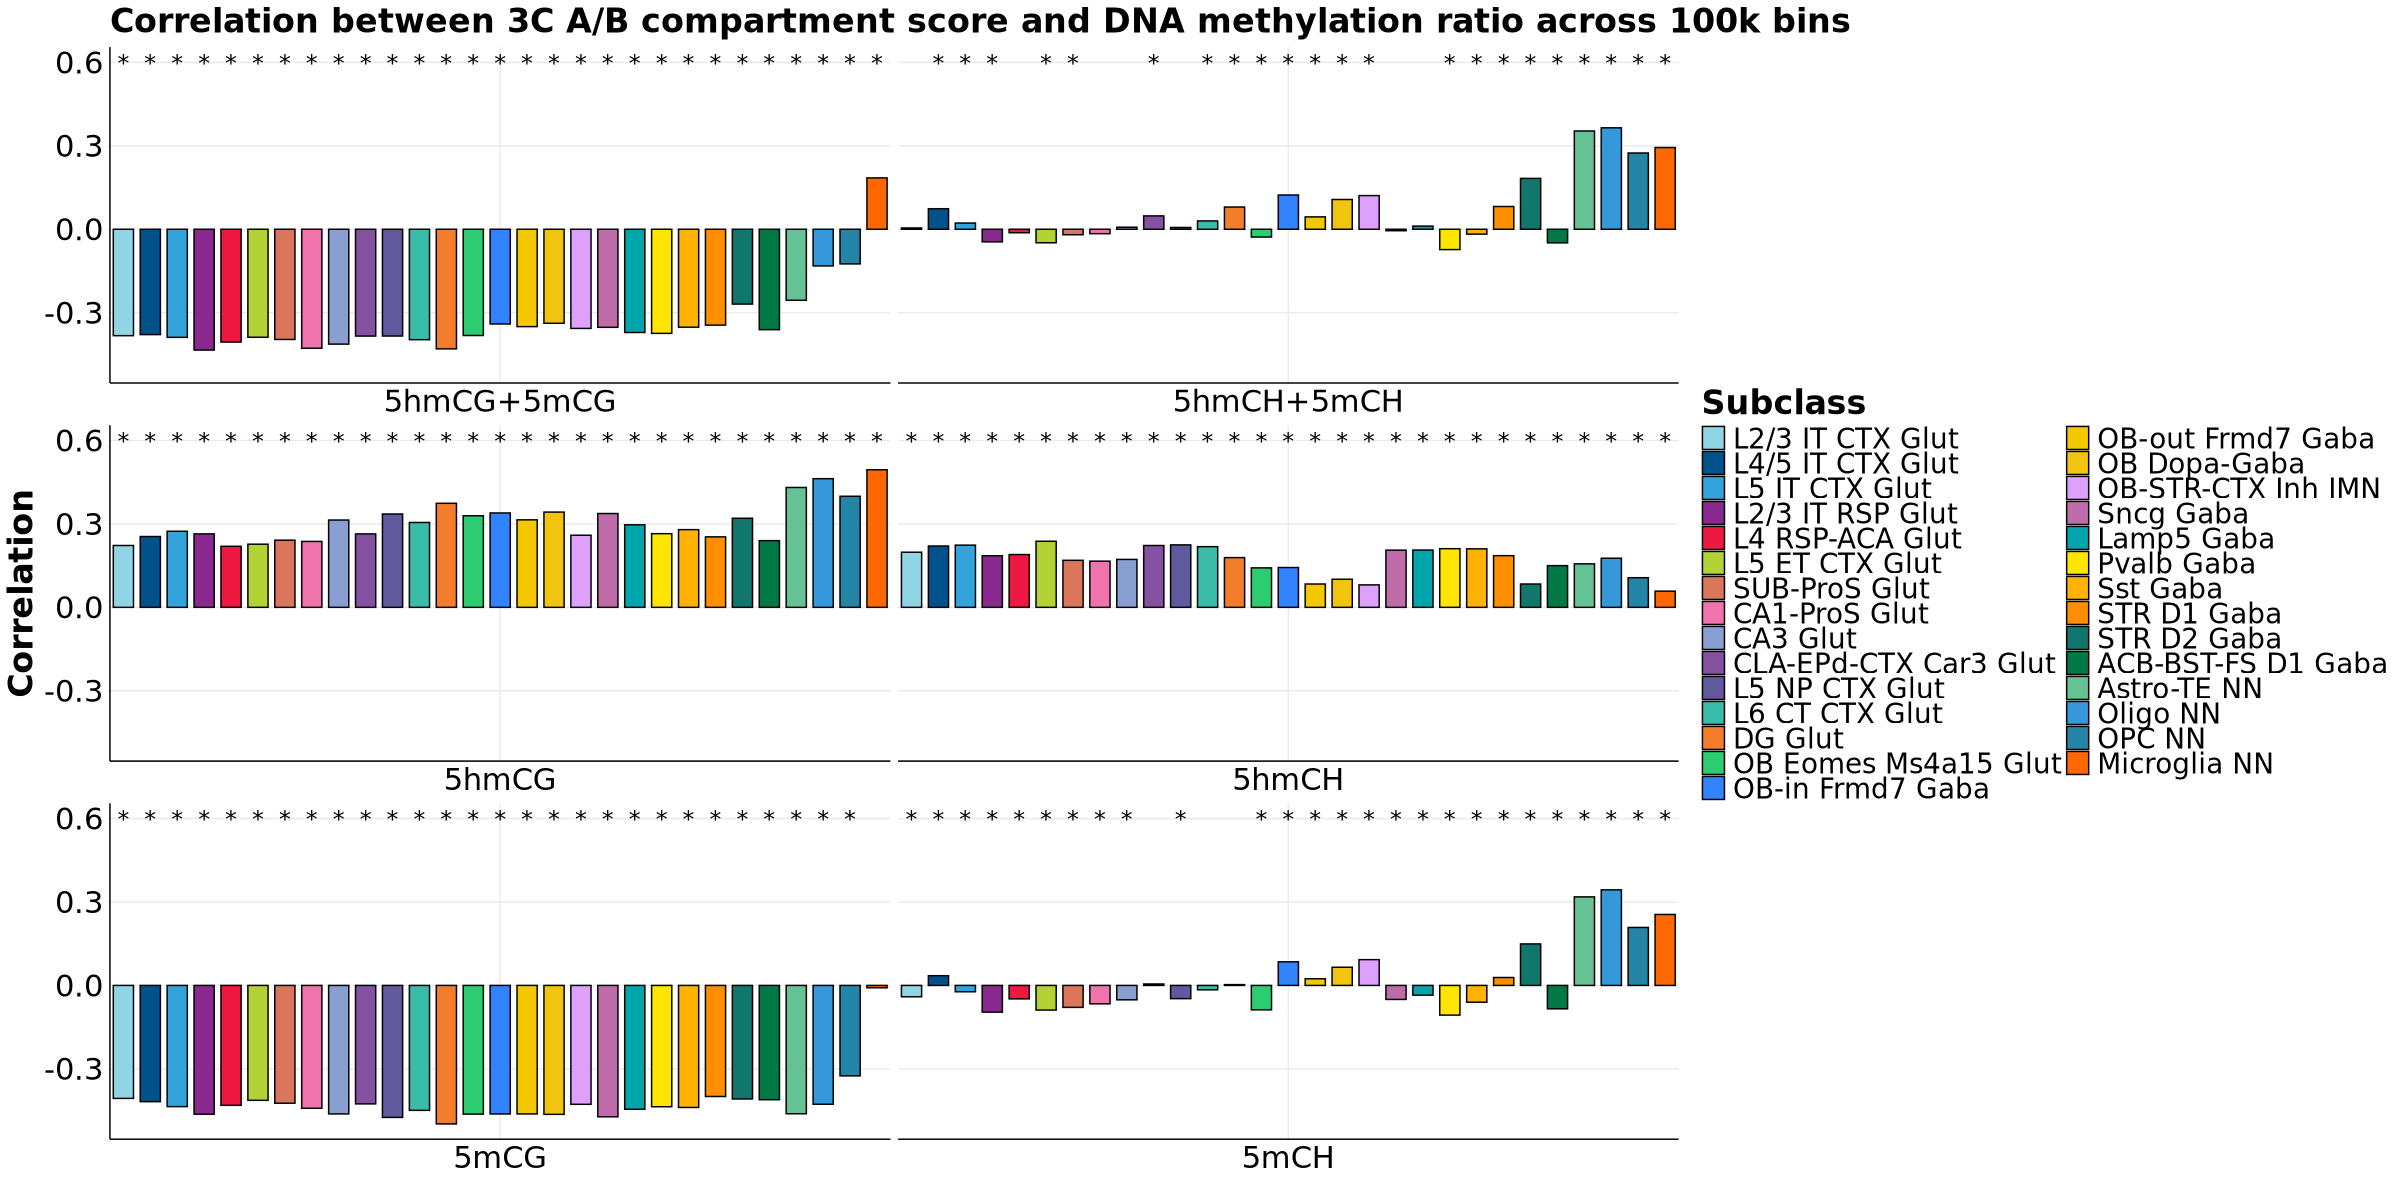

In [60]:
options(repr.plot.width = 24, repr.plot.height = 12, repr.plot.res = 100)
ggplot(all_correlations, aes(x = Group, y = correlation, fill = subclass)) +
  geom_bar(stat = "identity", position = position_dodge(width = 1.2), color = "black") +
  geom_text(aes(x = Group, y = 0.6, label = significance, group = subclass), 
            position = position_dodge(width = 1.2), 
            size = 6) +
  theme_minimal() +
  scale_fill_manual(values = subclassUsed.col) +
  labs(title = "Correlation between 3C A/B compartment score and DNA methylation ratio across 100k bins",
       x = "",
       y = "Correlation",
       fill = "Subclass") +
  theme(plot.title = element_text(size = 24, face = "bold"),
        axis.text.x = element_text(size = 22, color = "black"), # , angle = 45, hjust = 1
        axis.text.y = element_text(size = 22, color = "black"),
        axis.title.y = element_text(size = 24, color = "black", face = "bold"),
        legend.text = element_text(size = 20, color = "black"),
        legend.title = element_text(size = 24, face = "bold", color = "black"),
        strip.text = element_blank(),
        panel.grid.major = element_line(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(color = "black"),
        legend.position = "right") +
  facet_wrap(~ Group, scales = "free_x", nrow = 3)

In [61]:
all_correlations

subclass,correlation,p_value,Group,significance
<fct>,<dbl>,<dbl>,<fct>,<chr>
L2/3 IT CTX Glut,0.2224626,3.278419e-267,5hmCG,*
L4/5 IT CTX Glut,0.2547224,0.000000e+00,5hmCG,*
L5 IT CTX Glut,0.2736434,0.000000e+00,5hmCG,*
L2/3 IT RSP Glut,0.2642071,0.000000e+00,5hmCG,*
L4 RSP-ACA Glut,0.2194816,6.042777e-260,5hmCG,*
L5 ET CTX Glut,0.2271405,9.108250e-279,5hmCG,*
SUB-ProS Glut,0.2415762,3.860511e-316,5hmCG,*
CA1-ProS Glut,0.2370252,4.336952e-304,5hmCG,*
CA3 Glut,0.3139932,0.000000e+00,5hmCG,*


In [62]:
all_correlations <- all_correlations %>%
  mutate(
    omics = case_when(
      Group %in% c("5hmCG", "5hmCH") ~ "5hmC",
      Group %in% c("5hmCG+5mCG", "5hmCH+5mCH") ~ "5hmC+5mC",
      Group %in% c("5mCG", "5mCH") ~ "5mC",
      TRUE ~ Group
    ),
    modification = case_when(
      Group %in% c("5hmCG", "5hmCG+5mCG", "5mCG") ~ "CG",
      Group %in% c("5hmCH", "5hmCH+5mCH", "5mCH") ~ "CH",
      TRUE ~ "Unknown"
    )
  )

In [63]:
all_correlations

subclass,correlation,p_value,Group,significance,omics,modification
<fct>,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
L2/3 IT CTX Glut,0.2224626,3.278419e-267,5hmCG,*,5hmC,CG
L4/5 IT CTX Glut,0.2547224,0.000000e+00,5hmCG,*,5hmC,CG
L5 IT CTX Glut,0.2736434,0.000000e+00,5hmCG,*,5hmC,CG
L2/3 IT RSP Glut,0.2642071,0.000000e+00,5hmCG,*,5hmC,CG
L4 RSP-ACA Glut,0.2194816,6.042777e-260,5hmCG,*,5hmC,CG
L5 ET CTX Glut,0.2271405,9.108250e-279,5hmCG,*,5hmC,CG
SUB-ProS Glut,0.2415762,3.860511e-316,5hmCG,*,5hmC,CG
CA1-ProS Glut,0.2370252,4.336952e-304,5hmCG,*,5hmC,CG
CA3 Glut,0.3139932,0.000000e+00,5hmCG,*,5hmC,CG


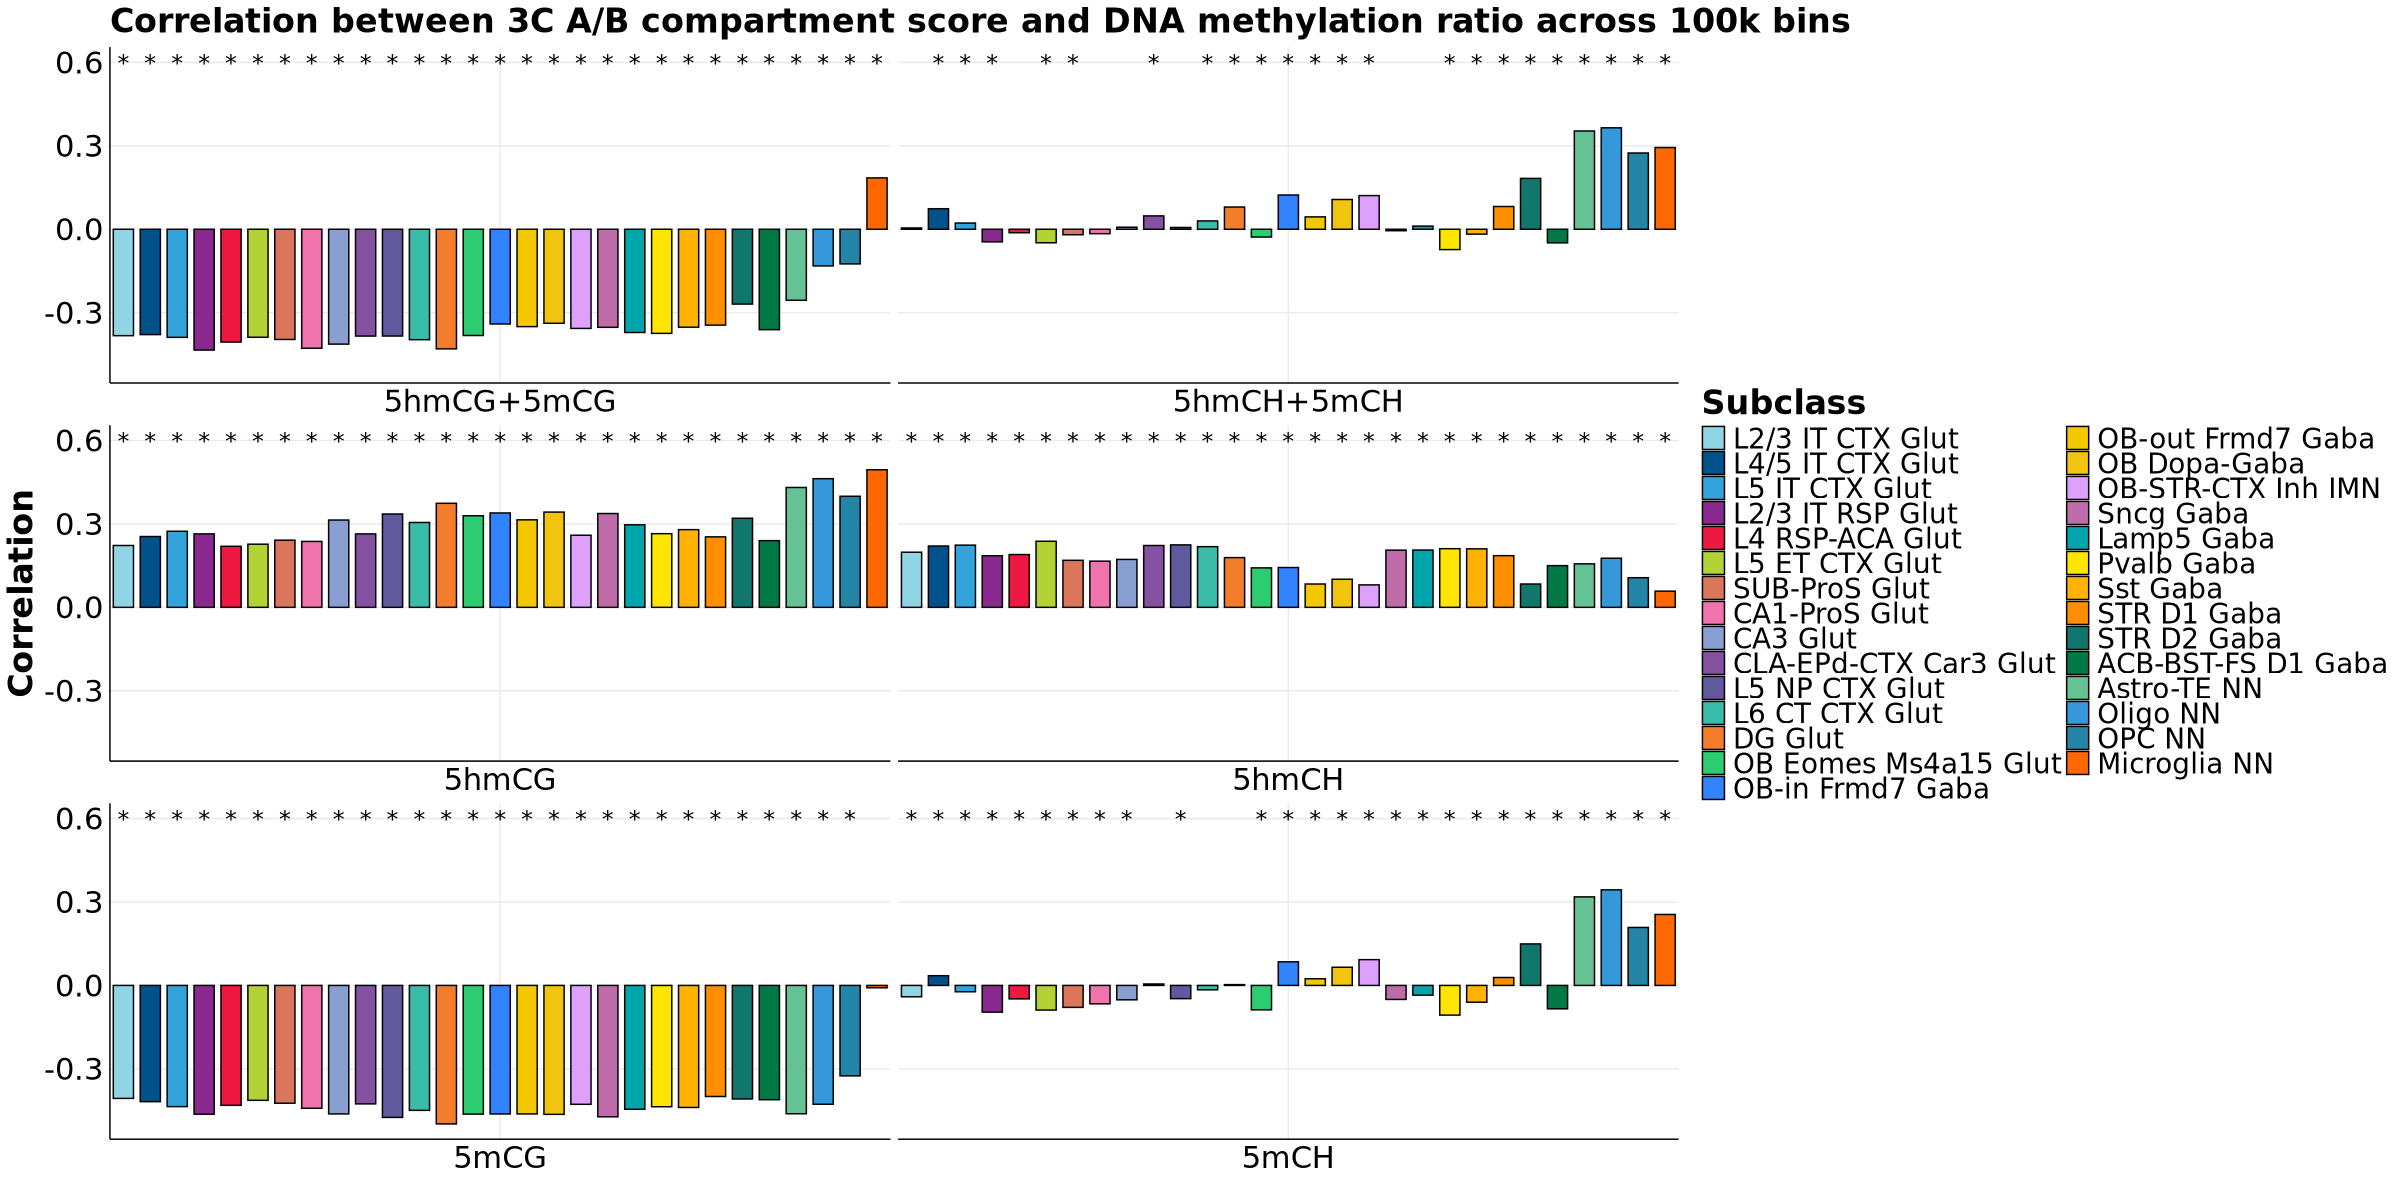

In [73]:
options(repr.plot.width = 24, repr.plot.height = 12, repr.plot.res = 100)
ggplot(all_correlations, aes(x = Group, y = correlation, fill = subclass)) +
  geom_bar(stat = "identity", position = position_dodge(width = 1.2), color = "black") +
  geom_text(aes(x = Group, y = 0.6, label = significance, group = subclass),
            position = position_dodge(width = 1.2),
            size = 6) +
  theme_minimal() +
  scale_fill_manual(values = subclassUsed.col) +
  labs(title = "Correlation between 3C A/B compartment score and DNA methylation ratio across 100k bins",
       x = "",
       y = "Correlation",
       fill = "Subclass") +
  theme(plot.title = element_text(size = 24, face = "bold"),
        axis.text.x = element_text(size = 22, color = "black"),
        axis.text.y = element_text(size = 22, color = "black"),
        axis.title.y = element_text(size = 24, color = "black", face = "bold"),
        legend.text = element_text(size = 20, color = "black"),
        legend.title = element_text(size = 24, face = "bold", color = "black"),
        strip.text = element_blank(),
        panel.grid.major = element_line(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(color = "black"),
        legend.position = "right") +
  facet_wrap(~ Group, scales = "free_x", nrow = 3)

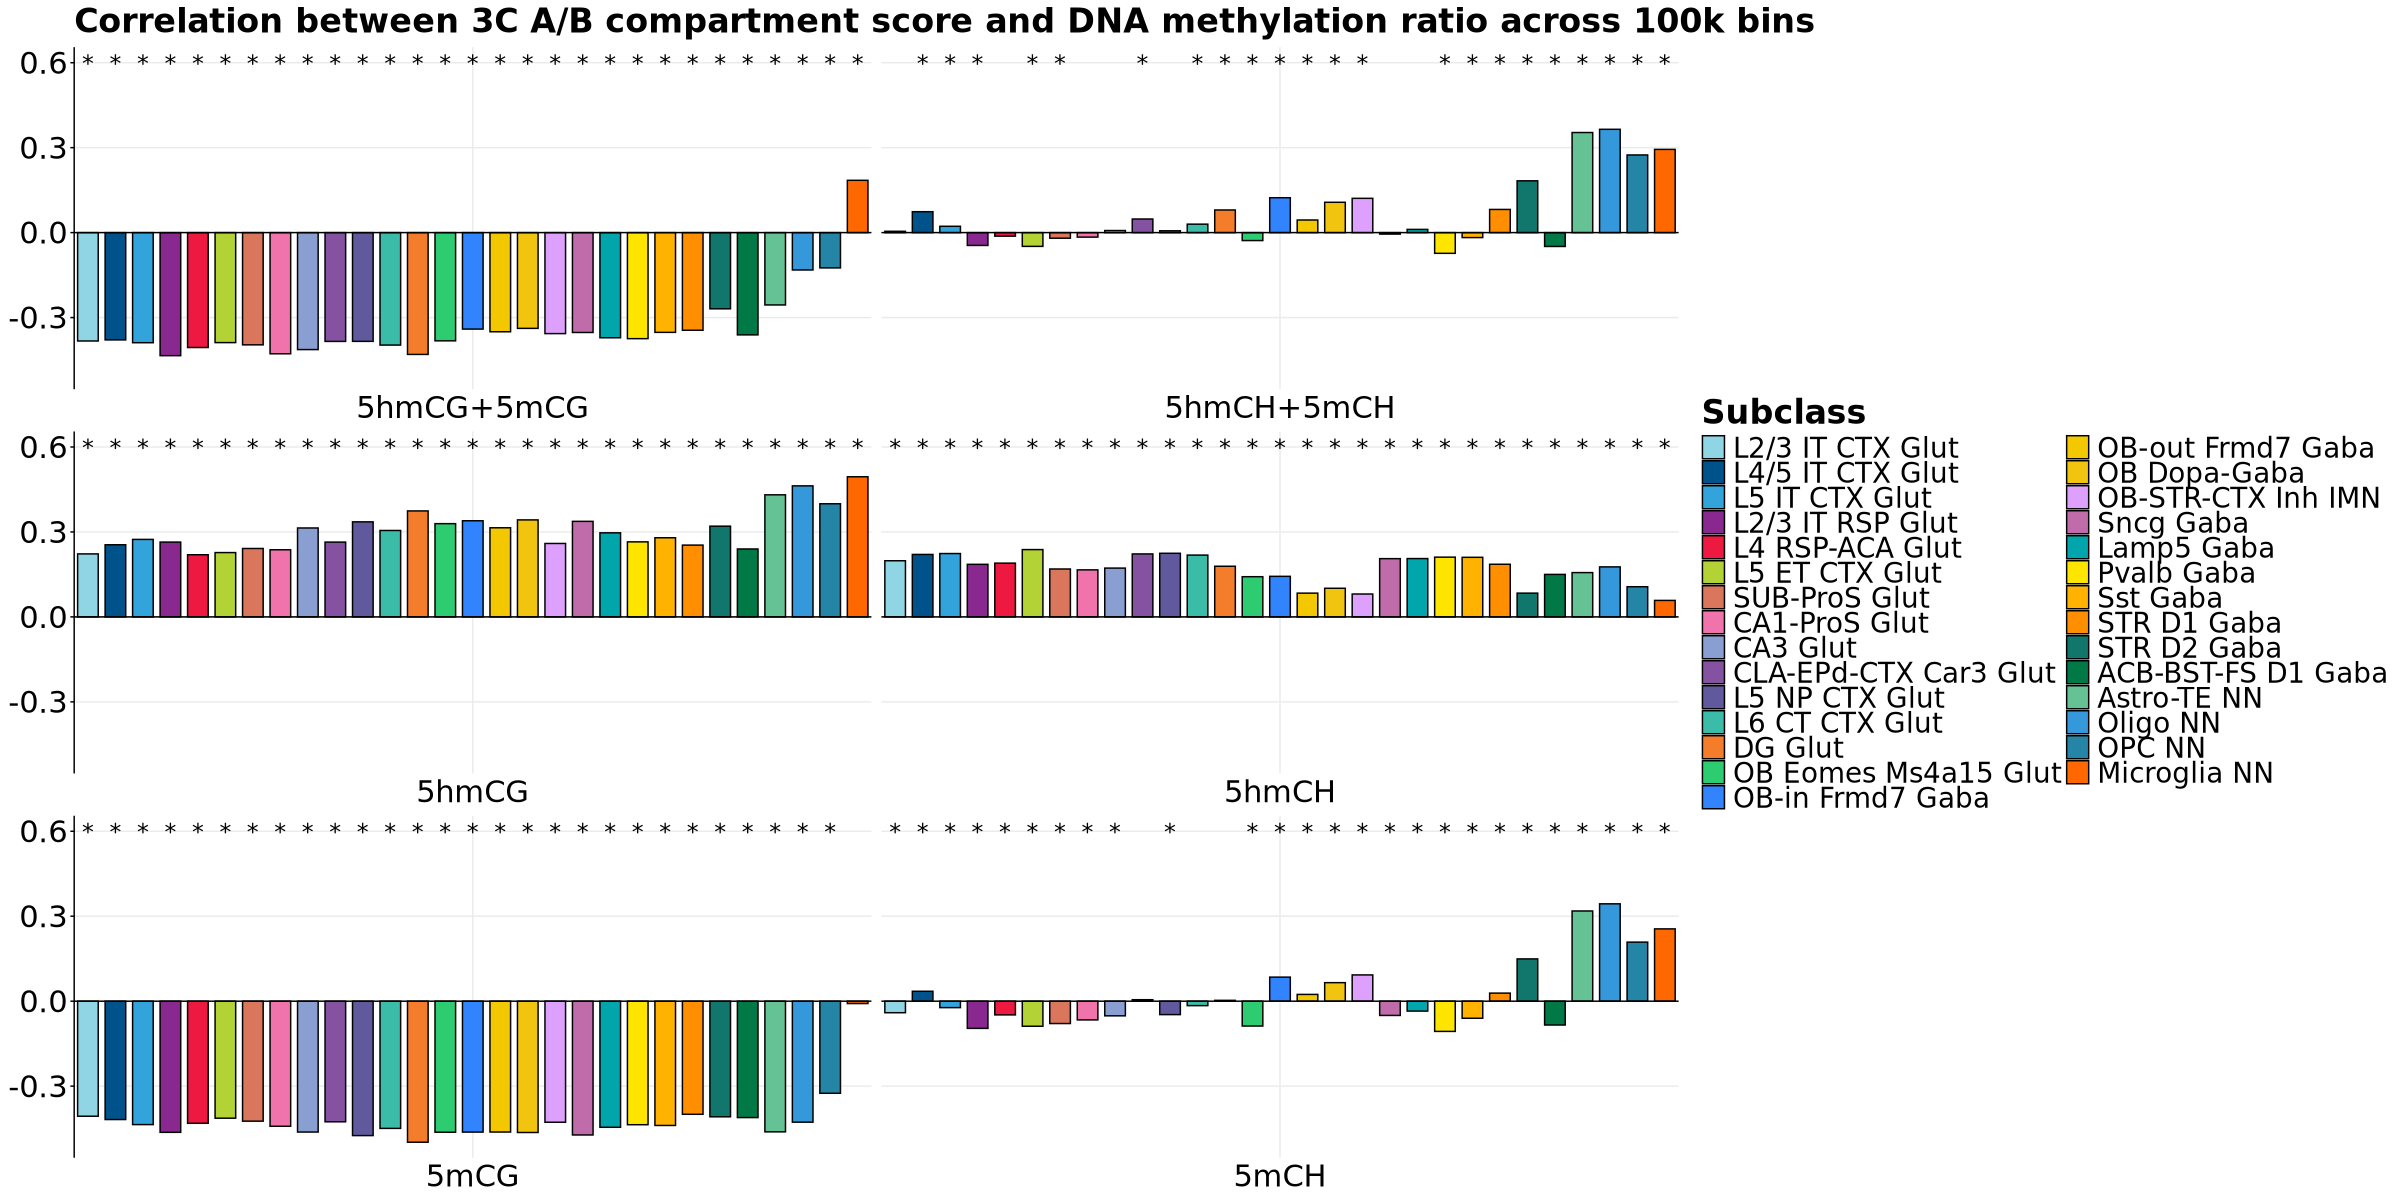

In [76]:
ggplot(all_correlations, aes(x = Group, y = correlation, fill = subclass)) +
  geom_bar(stat = "identity", position = position_dodge(width = 1.2), color = "black") +
  geom_text(aes(x = Group, y = 0.6, label = significance, group = subclass), 
            position = position_dodge(width = 1.2), 
            size = 6) +
  geom_hline(yintercept = 0, color = "black", linetype = "solid", size = 0.5) +
  theme_minimal() +
  scale_fill_manual(values = subclassUsed.col) +
  labs(title = "Correlation between 3C A/B compartment score and DNA methylation ratio across 100k bins",
       x = "",
       y = "Correlation",
       fill = "Subclass") +
  theme(
    plot.title = element_text(size = 24, face = "bold"),
    axis.text.x = element_text(size = 22, color = "black"),
    axis.text.y = element_text(size = 22, color = "black"),
    axis.title.y = element_blank(),
    axis.title.x = element_blank(),
    legend.text = element_text(size = 20, color = "black"),
    legend.title = element_text(size = 24, face = "bold", color = "black"),
    strip.text = element_blank(),
    panel.grid.major = element_line(),
    panel.grid.minor = element_blank(),
    axis.line = element_blank(),
    legend.position = "right"
  ) +
  facet_wrap(~ Group, scales = "free_x", nrow = 3) +
  theme(
    strip.text = element_blank(),
    axis.text.y = element_text(size = 22, color = "black"),
    axis.ticks.y = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    panel.spacing.x = unit(0.5, "lines")
  )

In [ ]:
pdf("../../../output/01-youth/05-AB_compartment/09-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score_barplot_including_sig_20250105.pdf",width = 24,height = 12)
ggplot(all_correlations, aes(x = Group, y = correlation, fill = subclass)) +
  geom_bar(stat = "identity", position = position_dodge(width = 1.2), color = "black") +
  geom_text(aes(x = Group, y = 0.6, label = significance, group = subclass), 
            position = position_dodge(width = 1.2), 
            size = 6) +
  geom_hline(yintercept = 0, color = "black", linetype = "solid", size = 0.5) +
  theme_minimal() +
  scale_fill_manual(values = subclassUsed.col) +
  labs(title = "Correlation between 3C A/B compartment score and DNA methylation ratio across 100k bins",
       x = "",
       y = "Correlation",
       fill = "Subclass") +
  theme(
    plot.title = element_text(size = 24, face = "bold"),
    axis.text.x = element_text(size = 22, color = "black"),
    axis.text.y = element_text(size = 22, color = "black"),
    axis.title.y = element_blank(),
    axis.title.x = element_blank(),
    legend.text = element_text(size = 20, color = "black"),
    legend.title = element_text(size = 24, face = "bold", color = "black"),
    strip.text = element_blank(),
    panel.grid.major = element_line(),
    panel.grid.minor = element_blank(),
    axis.line = element_blank(),
    legend.position = "right"
  ) +
  facet_wrap(~ Group, scales = "free_x", nrow = 3) +
  theme(
    strip.text = element_blank(),
    axis.text.y = element_text(size = 22, color = "black"),
    axis.ticks.y = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    panel.spacing.x = unit(0.5, "lines")
  )
dev.off()

png 
  2

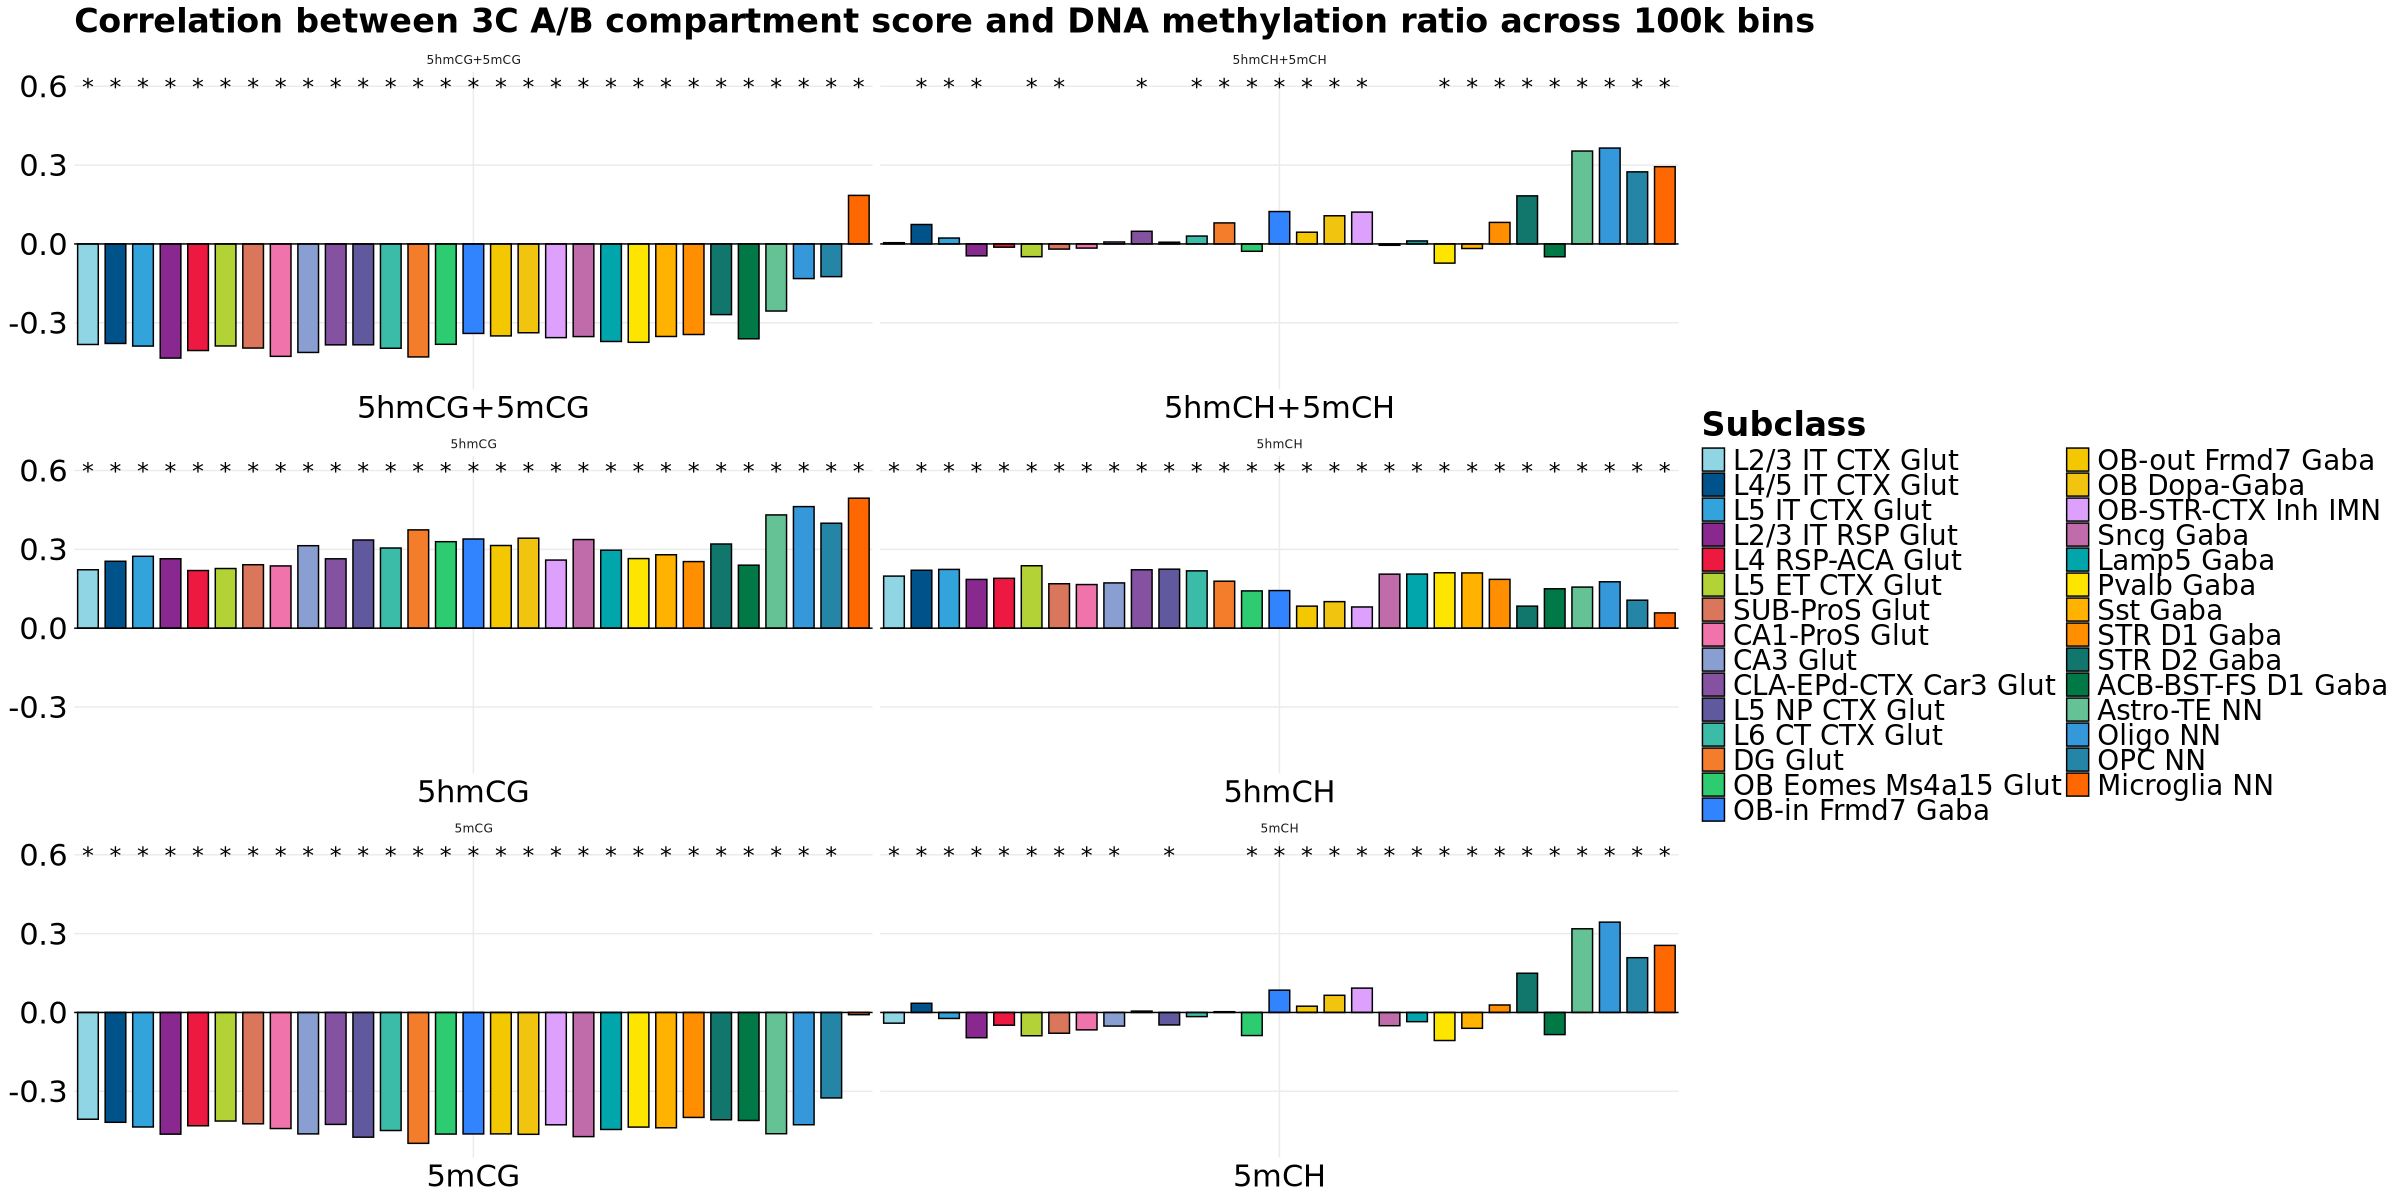

In [72]:
options(repr.plot.width = 24, repr.plot.height = 12, repr.plot.res = 100)
ggplot(all_correlations, aes(x = Group, y = correlation, fill = subclass)) +
  geom_bar(stat = "identity", position = position_dodge(width = 1.2), color = "black") +
  geom_text(aes(x = Group, y = 0.6, label = significance, group = subclass), 
            position = position_dodge(width = 1.2), 
            size = 6) +
  geom_hline(yintercept = 0, color = "black", linetype = "solid", size = 0.5) +
  theme_minimal() +
  scale_fill_manual(values = subclassUsed.col) +
  labs(title = "Correlation between 3C A/B compartment score and DNA methylation ratio across 100k bins",
       x = "",
       y = "Correlation",
       fill = "Subclass") +
  theme(
    plot.title = element_text(size = 24, face = "bold"),
    axis.text.x = element_text(size = 22, color = "black"),
    axis.text.y = element_text(size = 22, color = "black"),
    axis.title.y = element_blank(),
    axis.title.x = element_blank(),
    legend.text = element_text(size = 20, color = "black"),
    legend.title = element_text(size = 24, face = "bold", color = "black"),
    strip.text = element_text(),
    panel.grid.major = element_line(),
    panel.grid.minor = element_blank(),
    axis.line = element_blank(),
    legend.position = "right"
  ) +
  facet_wrap(~ Group, scales = "free_x", nrow = 3)

In [ ]:
options(repr.plot.width = 24, repr.plot.height = 12, repr.plot.res = 100)
ggplot(all_correlations, aes(x = Group, y = correlation, fill = subclass)) +
  geom_bar(stat = "identity", position = position_dodge(width = 1.2), color = "black") +
  geom_text(aes(x = Group, y = 0.6, label = significance, group = subclass), 
            position = position_dodge(width = 1.2), 
            size = 6) +
  theme_minimal() +
  scale_fill_manual(values = subclassUsed.col) +
  labs(title = "Correlation between 3C A/B compartment score and DNA methylation ratio across 100k bins",
       x = "",
       y = "Correlation",
       fill = "Subclass") +
  theme(plot.title = element_text(size = 24, face = "bold"),
        axis.text.x = element_text(size = 22, color = "black"), # , angle = 45, hjust = 1
        axis.text.y = element_text(size = 22, color = "black"),
        axis.title.y = element_text(size = 24, color = "black", face = "bold"),
        legend.text = element_text(size = 20, color = "black"),
        legend.title = element_text(size = 24, face = "bold", color = "black"),
        strip.text = element_blank(),
        panel.grid.major = element_line(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(color = "black"),
        legend.position = "right") +
  facet_wrap(~ Group, scales = "free_x", nrow = 3)

In [ ]:
pdf(paste0(outdir,"/09-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score_barplot_including_sig.pdf"),width = 24,height = 12)
ggplot(all_correlations, aes(x = Group, y = correlation, fill = subclass)) +
  geom_bar(stat = "identity", position = position_dodge(width = 1.2), color = "black") +
  geom_text(aes(x = Group, y = 0.6, label = significance, group = subclass), 
            position = position_dodge(width = 1.2), 
            size = 6) +
  theme_minimal() +
  scale_fill_manual(values = subclassUsed.col) +
  labs(title = "Correlation between 3C A/B compartment score and DNA methylation ratio across 100k bins",
       x = "",
       y = "Correlation",
       fill = "Subclass") +
  theme(plot.title = element_text(size = 24, face = "bold"),
        axis.text.x = element_text(size = 22, color = "black"), # , angle = 45, hjust = 1
        axis.text.y = element_text(size = 22, color = "black"),
        axis.title.y = element_text(size = 24, color = "black", face = "bold"),
        legend.text = element_text(size = 20, color = "black"),
        legend.title = element_text(size = 24, face = "bold", color = "black"),
        strip.text = element_blank(),
        panel.grid.major = element_line(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(color = "black"),
        legend.position = "right") +
  facet_wrap(~ Group, scales = "free_x", nrow = 3)
dev.off()

png 
  2

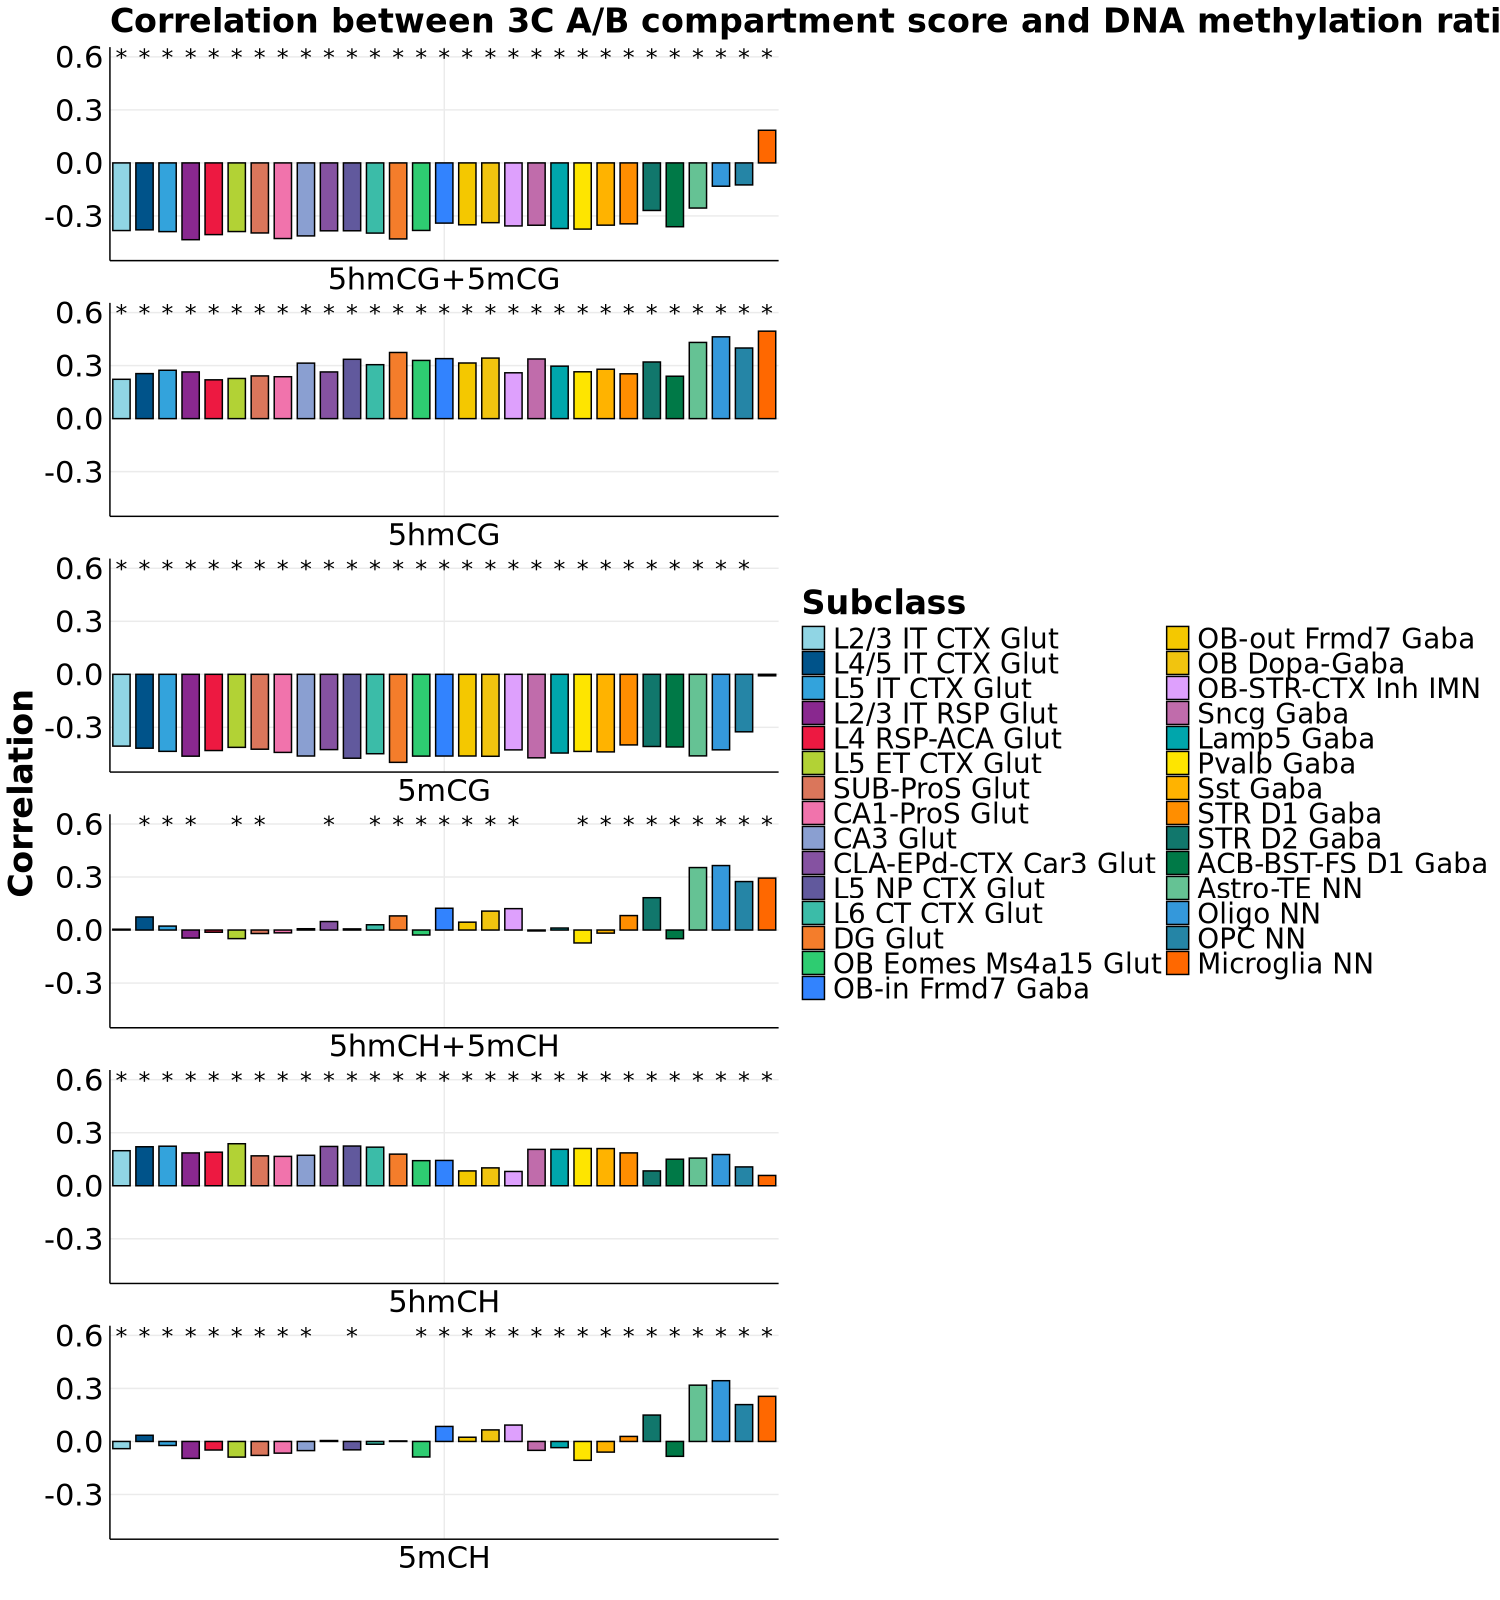

In [66]:
options(repr.plot.width = 15, repr.plot.height = 16, repr.plot.res = 100)
ggplot(all_correlations, aes(x = Group, y = correlation, fill = subclass)) +
  geom_bar(stat = "identity", position = position_dodge(width = 1.2), color = "black") +
  geom_text(aes(x = Group, y = 0.6, label = significance, group = subclass), 
            position = position_dodge(width = 1.2), 
            size = 6) +
  theme_minimal() +
  scale_fill_manual(values = subclassUsed.col) +
  labs(title = "Correlation between 3C A/B compartment score and DNA methylation ratio across 100k bins",
       x = "",
       y = "Correlation",
       fill = "Subclass") +
  theme(plot.title = element_text(size = 24, face = "bold"),
        axis.text.x = element_text(size = 22, color = "black"), # , angle = 45, hjust = 1
        axis.text.y = element_text(size = 22, color = "black"),
        axis.title.y = element_text(size = 24, color = "black", face = "bold"),
        legend.text = element_text(size = 20, color = "black"),
        legend.title = element_text(size = 24, face = "bold", color = "black"),
        strip.text = element_blank(),
        panel.grid.major = element_line(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(color = "black"),
        legend.position = "right") +
  facet_wrap(~ Group, scales = "free_x", nrow = 6)

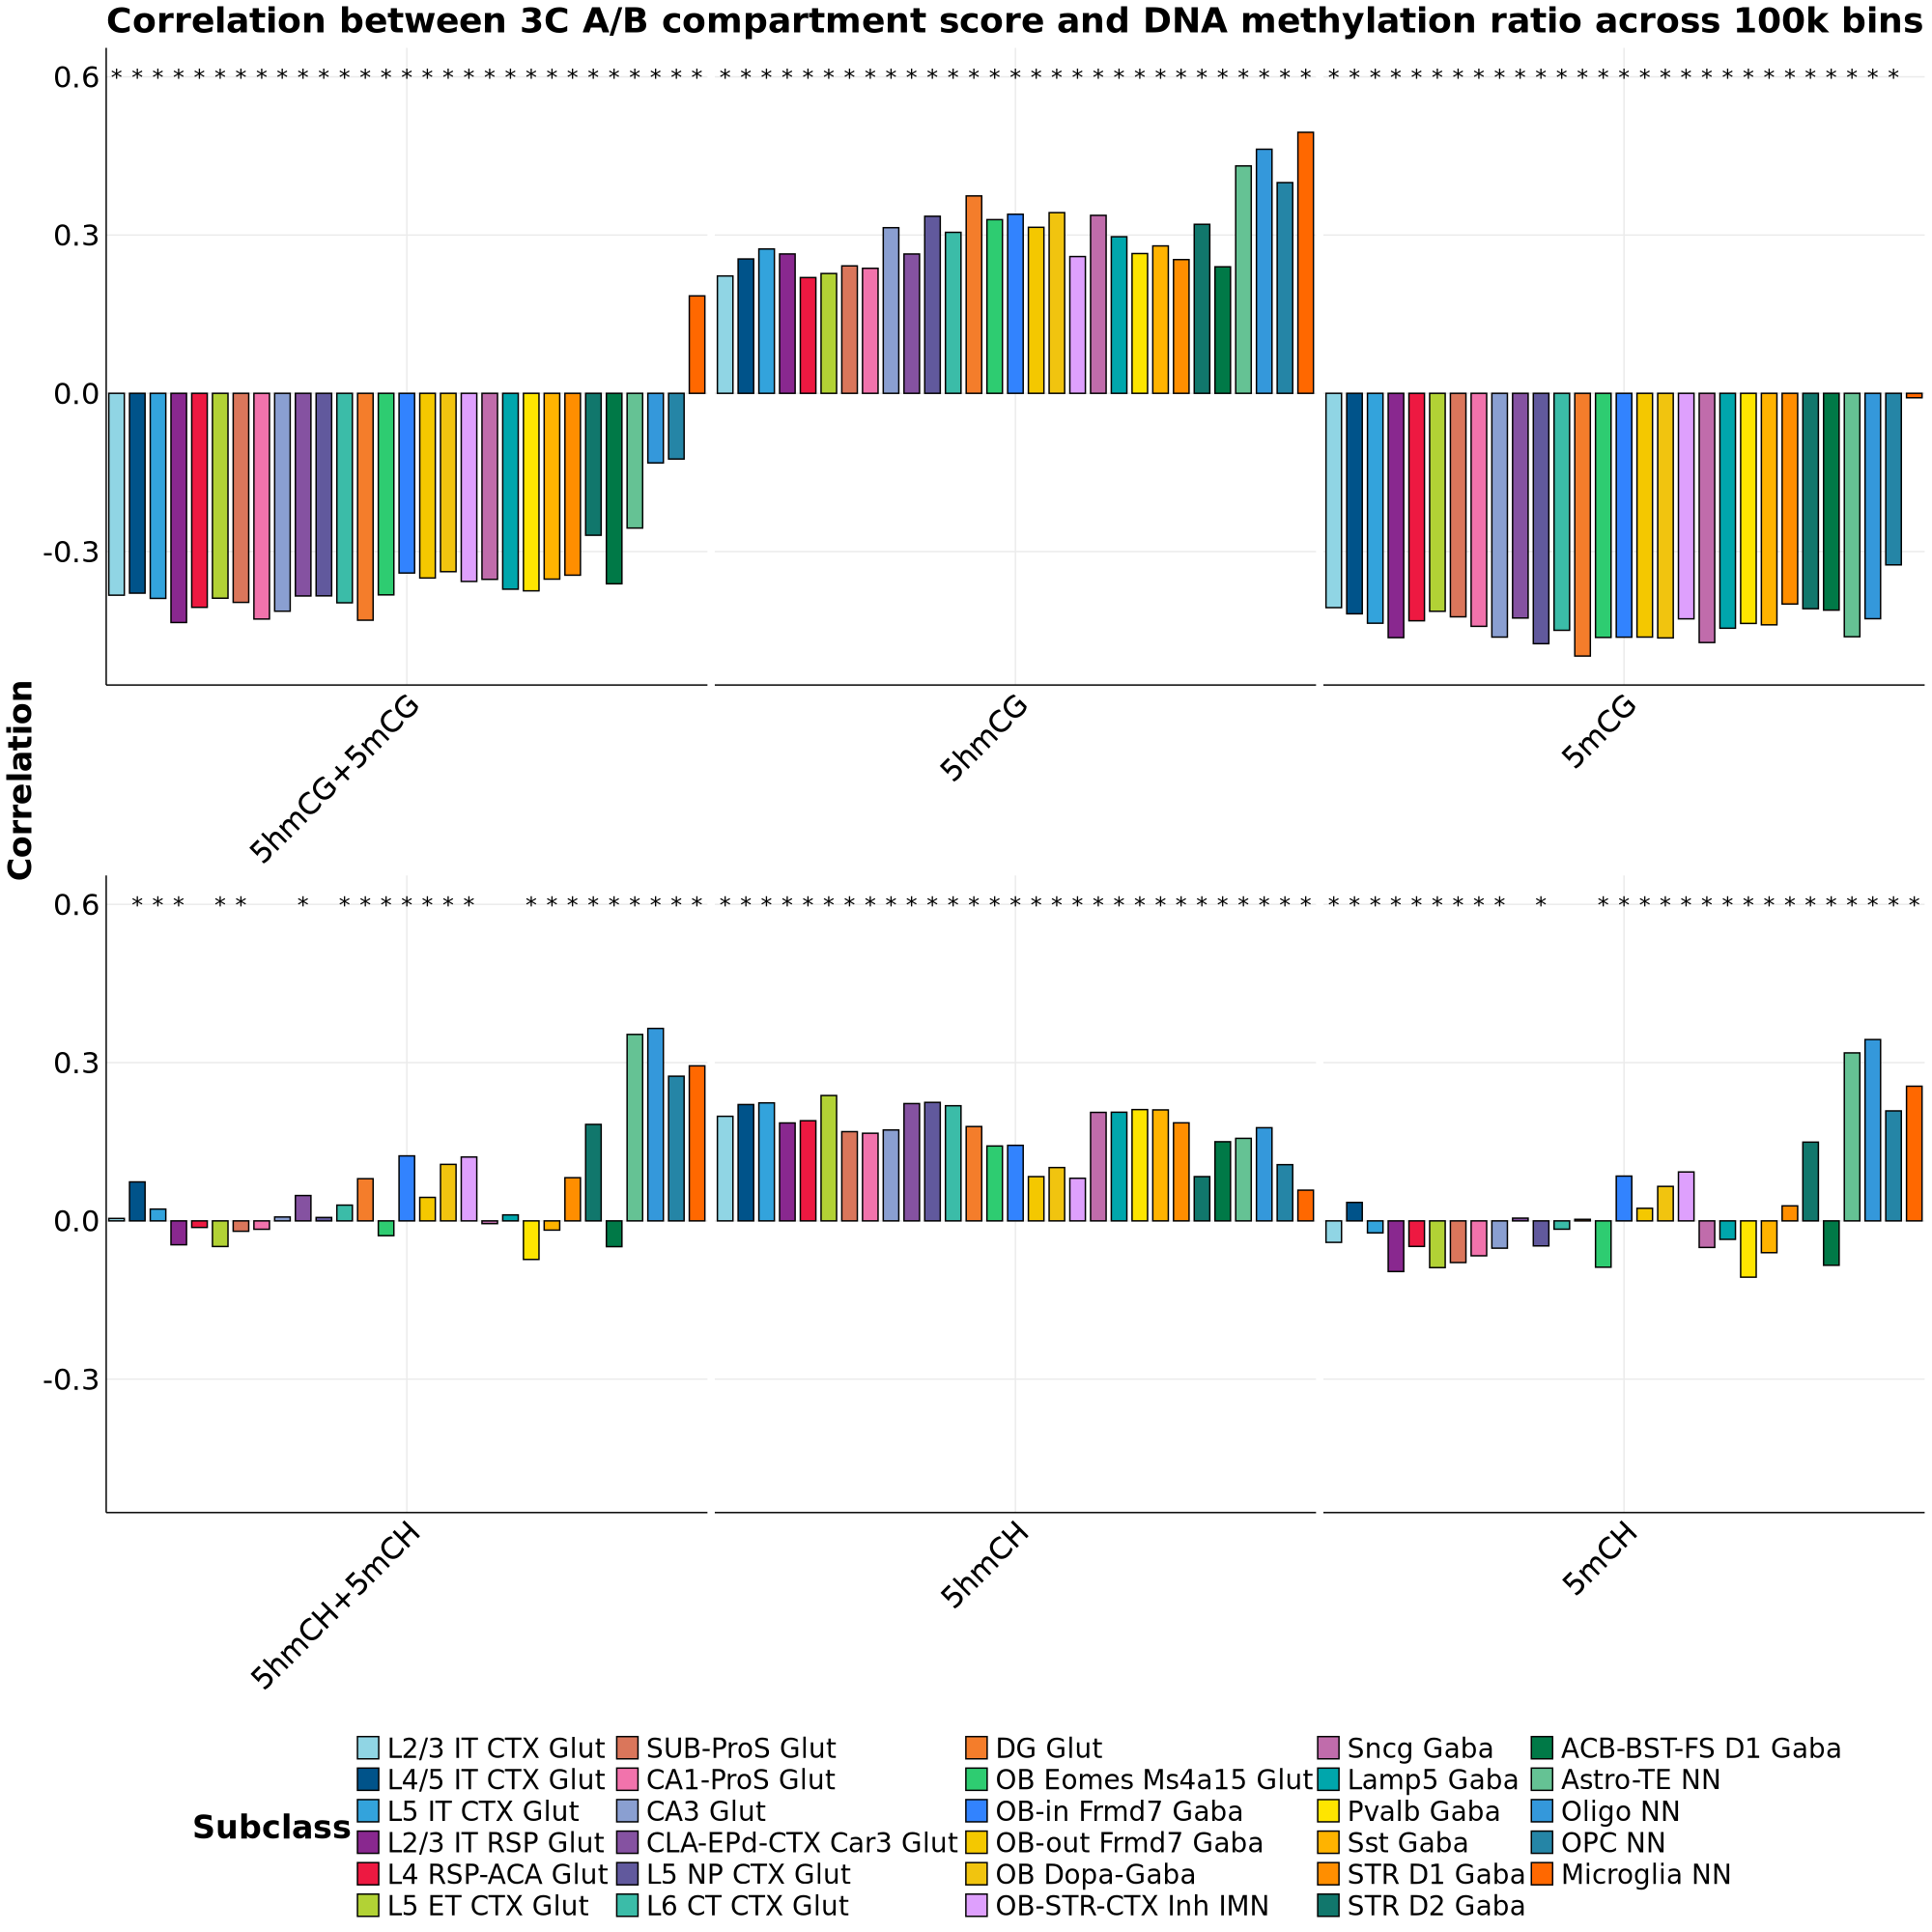

In [115]:
options(repr.plot.width = 20, repr.plot.height = 20, repr.plot.res = 100)
ggplot(all_correlations, aes(x = Group, y = correlation, fill = subclass)) +
  geom_bar(stat = "identity", position = position_dodge(width = 1.2), color = "black") +
  geom_text(aes(x = Group, y = 0.6, label = significance, group = subclass), 
            position = position_dodge(width = 1.2), 
            size = 6) +
  theme_minimal() +
  scale_fill_manual(values = subclassUsed.col) +
  labs(title = "Correlation between 3C A/B compartment score and DNA methylation ratio across 100k bins",
       x = "",
       y = "Correlation",
       fill = "Subclass") +
  theme(plot.title = element_text(size = 26, face = "bold"),
        axis.text.x = element_text(size = 22, color = "black", angle = 45, hjust = 1),
        axis.text.y = element_text(size = 22, color = "black"),
        axis.title.y = element_text(size = 24, color = "black", face = "bold"),
        legend.text = element_text(size = 20, color = "black"),
        legend.title = element_text(size = 24, face = "bold", color = "black"),
        strip.text = element_blank(),
        panel.grid.major = element_line(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(color = "black"),
        legend.position = "bottom") +
  facet_wrap(~ Group, scales = "free_x", nrow = 2)

In [ ]:
pdf(paste0(outdir,"/09-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score_barplot_including_sig.pdf"),width = 20,height = 12)
ggplot(all_correlations, aes(x = Group, y = correlation, fill = subclass)) +
  geom_bar(stat = "identity", position = position_dodge(width = 1.2), color = "black") +
  geom_text(aes(x = Group, y = 0.6, label = significance, group = subclass), 
            position = position_dodge(width = 1.2), 
            size = 8) +
  theme_minimal() +
  scale_fill_manual(values = subclassUsed.col) +
  labs(title = "Correlation between 3C A/B compartment score and DNA methylation ratio across 100k bins",
       x = "",
       y = "Correlation",
       fill = "Subclass") +
  theme(plot.title = element_text(size = 26, face = "bold"),
        axis.text.x = element_text(size = 22, color = "black", angle = 45, hjust = 1),
        axis.text.y = element_text(size = 22, color = "black"),
        axis.title.y = element_text(size = 24, color = "black", face = "bold"),
        legend.text = element_text(size = 20, color = "black"),
        legend.title = element_text(size = 24, face = "bold", color = "black"),
        strip.text = element_blank(),
        panel.grid.major = element_line(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(color = "black"),
        legend.position = "bottom") +
  facet_wrap(~ Group, scales = "free_x", nrow = 2)
dev.off()

png 
  2

In [74]:
library(dplyr)

In [75]:
all_correlations <- all_correlations %>%
  mutate(Direction = ifelse(correlation > 0, "Positive correlation", "Negative correlation"))
all_correlations

subclass,correlation,Group,Direction
<chr>,<dbl>,<chr>,<chr>
L2/3 IT CTX Glut,0.2224626,5hmCG,Positive correlation
L4/5 IT CTX Glut,0.2547224,5hmCG,Positive correlation
L5 IT CTX Glut,0.2736434,5hmCG,Positive correlation
L2/3 IT RSP Glut,0.2642071,5hmCG,Positive correlation
L4 RSP-ACA Glut,0.2194816,5hmCG,Positive correlation
L5 ET CTX Glut,0.2271405,5hmCG,Positive correlation
SUB-ProS Glut,0.2415762,5hmCG,Positive correlation
CA1-ProS Glut,0.2370252,5hmCG,Positive correlation
CA3 Glut,0.3139932,5hmCG,Positive correlation


In [76]:
subclass_order <- unlist(strsplit("L2/3 IT CTX Glut
L4/5 IT CTX Glut
L5 IT CTX Glut
L2/3 IT RSP Glut
L4 RSP-ACA Glut
L5 ET CTX Glut
SUB-ProS Glut
CA1-ProS Glut
CA3 Glut
CLA-EPd-CTX Car3 Glut
L5 NP CTX Glut
L6 CT CTX Glut
DG Glut
OB Eomes Ms4a15 Glut
OB-in Frmd7 Gaba
OB-out Frmd7 Gaba
OB Dopa-Gaba
OB-STR-CTX Inh IMN
Sncg Gaba
Lamp5 Gaba
Pvalb Gaba
Sst Gaba
STR D1 Gaba
STR D2 Gaba
ACB-BST-FS D1 Gaba
Astro-TE NN
Oligo NN
OPC NN
Microglia NN","\n"))

subclass_order

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "L2/3 IT RSP Glut"      "L4 RSP-ACA Glut"       "L5 ET CTX Glut"       
 [7] "SUB-ProS Glut"         "CA1-ProS Glut"         "CA3 Glut"             
[10] "CLA-EPd-CTX Car3 Glut" "L5 NP CTX Glut"        "L6 CT CTX Glut"       
[13] "DG Glut"               "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"     
[16] "OB-out Frmd7 Gaba"     "OB Dopa-Gaba"          "OB-STR-CTX Inh IMN"   
[19] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[22] "Sst Gaba"              "STR D1 Gaba"           "STR D2 Gaba"          
[25] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "Oligo NN"             
[28] "OPC NN"                "Microglia NN"

In [77]:
table(unique(all_correlations$subclass) %in% subclass_order)
table(subclass_order %in% unique(all_correlations$subclass))


TRUE 
  29 


TRUE 
  29 

In [78]:
levels(all_correlations$subclass)

NULL

In [79]:
all_correlations$subclass <- factor(all_correlations$subclass,levels = rev(subclass_order))

levels(all_correlations$subclass)

[1] "Microglia NN"          "OPC NN"                "Oligo NN"             
 [4] "Astro-TE NN"           "ACB-BST-FS D1 Gaba"    "STR D2 Gaba"          
 [7] "STR D1 Gaba"           "Sst Gaba"              "Pvalb Gaba"           
[10] "Lamp5 Gaba"            "Sncg Gaba"             "OB-STR-CTX Inh IMN"   
[13] "OB Dopa-Gaba"          "OB-out Frmd7 Gaba"     "OB-in Frmd7 Gaba"     
[16] "OB Eomes Ms4a15 Glut"  "DG Glut"               "L6 CT CTX Glut"       
[19] "L5 NP CTX Glut"        "CLA-EPd-CTX Car3 Glut" "CA3 Glut"             
[22] "CA1-ProS Glut"         "SUB-ProS Glut"         "L5 ET CTX Glut"       
[25] "L4 RSP-ACA Glut"       "L2/3 IT RSP Glut"      "L5 IT CTX Glut"       
[28] "L4/5 IT CTX Glut"      "L2/3 IT CTX Glut"

In [90]:
levels(all_correlations$Group)

NULL

In [91]:
unique(all_correlations$Group)

[1] "5hmCG"      "5hmCG+5mCG" "5mCG"       "5hmCH"      "5hmCH+5mCH"
[6] "5mCH"

In [92]:
all_correlations$Group <- factor(all_correlations$Group,
                                 levels = c('5hmCG+5mCG','5hmCG','5mCG','5hmCH+5mCH','5hmCH','5mCH'))

In [93]:
levels(all_correlations$Group)

[1] "5hmCG+5mCG" "5hmCG"      "5mCG"       "5hmCH+5mCH" "5hmCH"     
[6] "5mCH"

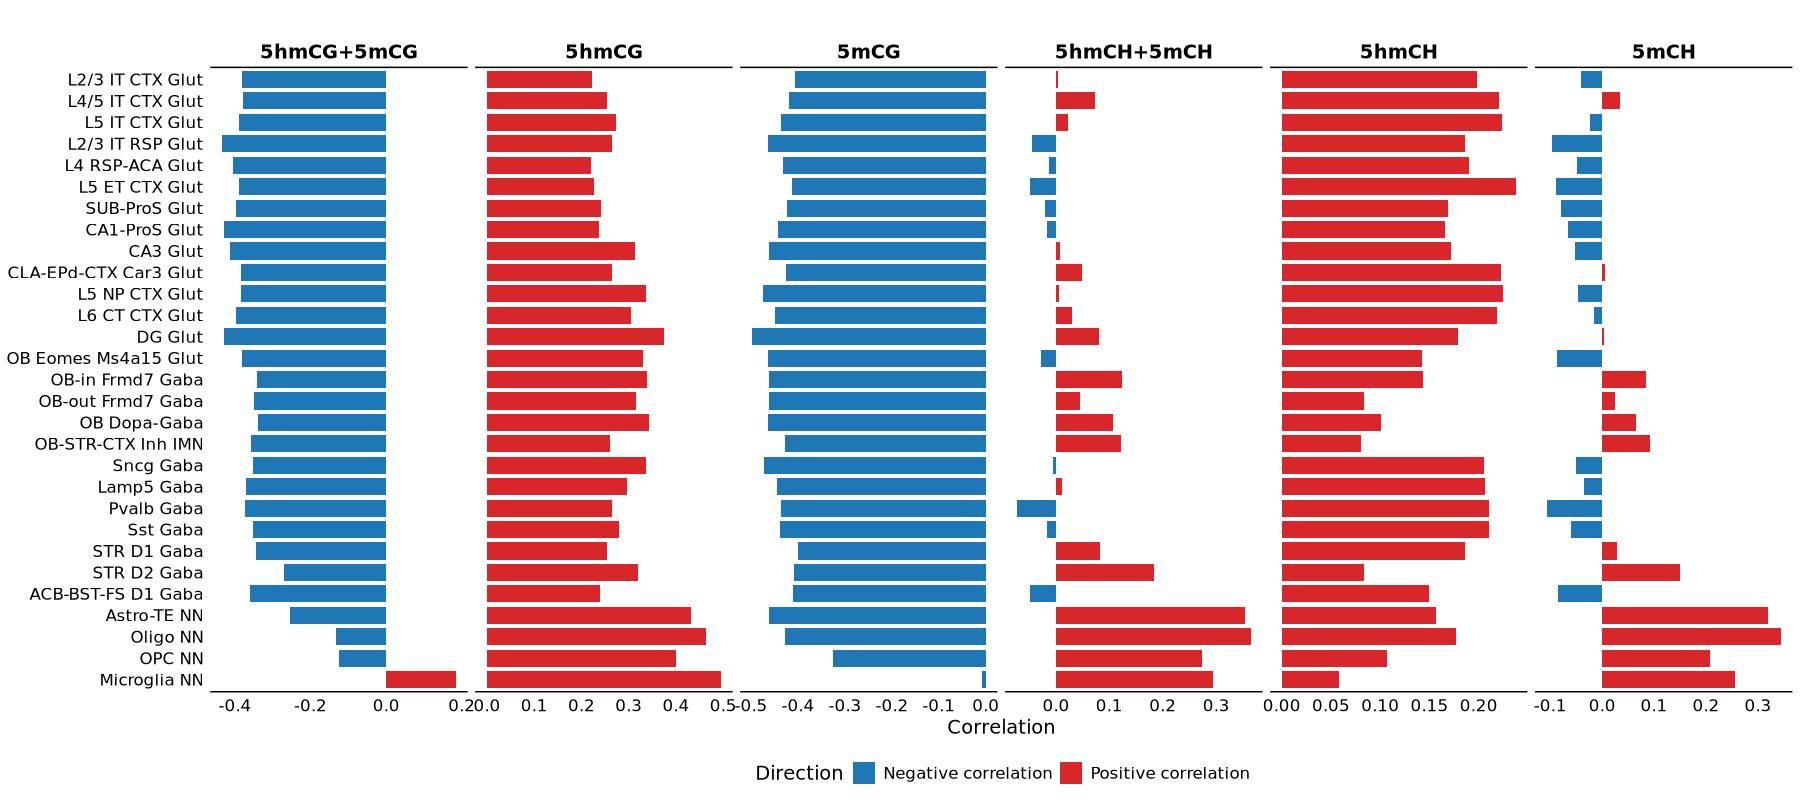

In [94]:
options(repr.plot.width = 18, repr.plot.height = 8, repr.plot.res = 100)
ggplot(all_correlations, aes(x = correlation, y = subclass, fill = Direction)) +
  geom_bar(stat = "identity", width = 0.8) +
  facet_wrap(~ Group, scales = "free_x", ncol = 6) +
  scale_fill_manual(values = c("Positive correlation" = "#D7272A", "Negative correlation" = "#2077B5")) +
  theme_minimal() +
  labs(
    x = "Correlation",
    y = NULL,
    fill = "Direction",
    title = ""
  ) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_blank(),
    axis.text = element_text(size = 12, color = "black"),
    axis.title = element_text(size = 14, color = "black"),
    strip.text = element_text(size = 14, face = "bold", color = "black"),
    legend.text = element_text(size = 12, color = "black"),
    legend.title = element_text(size = 14, color = "black"),
    legend.position = "bottom",
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5)
  ) +
  geom_hline(yintercept = Inf, color = "black", size = 1) +
  geom_hline(yintercept = -Inf, color = "black", size = 1)

In [ ]:
pdf("../../../output/01-youth/05-AB_compartment/09-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score_barplot.pdf",width = 18,height = 8)
ggplot(all_correlations, aes(x = correlation, y = subclass, fill = Direction)) +
  geom_bar(stat = "identity", width = 0.8) +
  facet_wrap(~ Group, scales = "free_x", ncol = 6) +
  scale_fill_manual(values = c("Positive correlation" = "#D7272A", "Negative correlation" = "#2077B5")) +
  theme_minimal() +
  labs(
    x = "Correlation",
    y = NULL,
    fill = "Direction",
    title = ""
  ) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_blank(),
    axis.text = element_text(size = 12, color = "black"),
    axis.title = element_text(size = 14, color = "black"),
    strip.text = element_text(size = 14, face = "bold", color = "black"),
    legend.text = element_text(size = 12, color = "black"),
    legend.title = element_text(size = 14, color = "black"),
    legend.position = "bottom",
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5)
  ) +
  geom_hline(yintercept = Inf, color = "black", size = 1) +
  geom_hline(yintercept = -Inf, color = "black", size = 1)
dev.off()

png 
  2

In [46]:
.libPaths()

[1] "/share/analysisdata/Methyl/public/rna/lib/R/library"

In [47]:
library(paletteer,lib.loc = "/share/home/yangf/.conda/envs/analysis/lib/R/library")
library(scales)

Warning message:
“package ‘scales’ was built under R version 4.3.2”


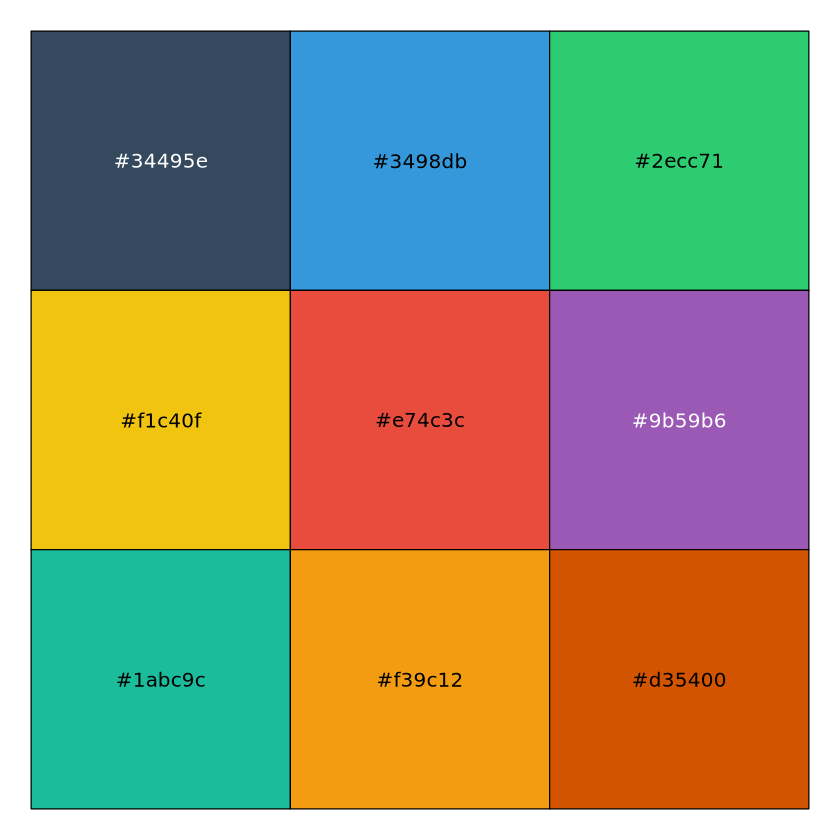

In [48]:
show_col(palettes_d$ggthemr$flat)

In [49]:
unique(all_correlations$Group)

[1] "5hmCG"      "5hmCG+5mCG" "5mCG"       "5hmCH"      "5hmCH+5mCH"
[6] "5mCH"

In [50]:
group.col <- setNames(rev(palettes_d$ggthemr$flat[1:6]),unique(all_correlations$Group))
group.col

5hmCG 5hmCG+5mCG       5mCG      5hmCH 5hmCH+5mCH       5mCH 
 "#9b59b6"  "#e74c3c"  "#f1c40f"  "#2ecc71"  "#3498db"  "#34495e"

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


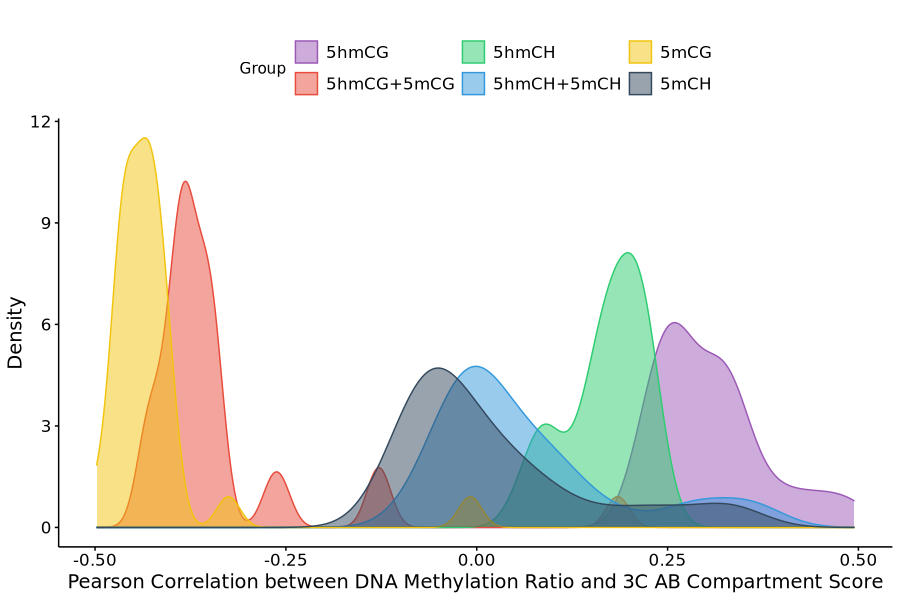

In [51]:
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 100)
ggplot(all_correlations, aes(x = correlation, fill = Group, color = Group)) +
  geom_density(alpha = 0.5) +
  theme_minimal() +
  labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
  scale_fill_manual(values = group.col) +
  scale_color_manual(values = group.col) +
  theme(
    legend.position = "top",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )

In [52]:
pic <- ggplot(all_correlations, aes(x = correlation, fill = Group, color = Group)) +
  geom_density(alpha = 0.5) +
  theme_minimal() +
  labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
  scale_fill_manual(values = group.col) +
  scale_color_manual(values = group.col) +
  theme(
    legend.position = "top",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )

In [ ]:
pdf("../../../output/01-youth/05-AB_compartment/09-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score.pdf",width = 9,height = 6)
pic
dev.off()

png 
  2

In [52]:
all_correlations

subclass,correlation,Group
<chr>,<dbl>,<chr>
L2/3 IT CTX Glut,0.2224626,5hmCG
L4/5 IT CTX Glut,0.2547224,5hmCG
L5 IT CTX Glut,0.2736434,5hmCG
L2/3 IT RSP Glut,0.2642071,5hmCG
L4 RSP-ACA Glut,0.2194816,5hmCG
L5 ET CTX Glut,0.2271405,5hmCG
SUB-ProS Glut,0.2415762,5hmCG
CA1-ProS Glut,0.2370252,5hmCG
CA3 Glut,0.3139932,5hmCG


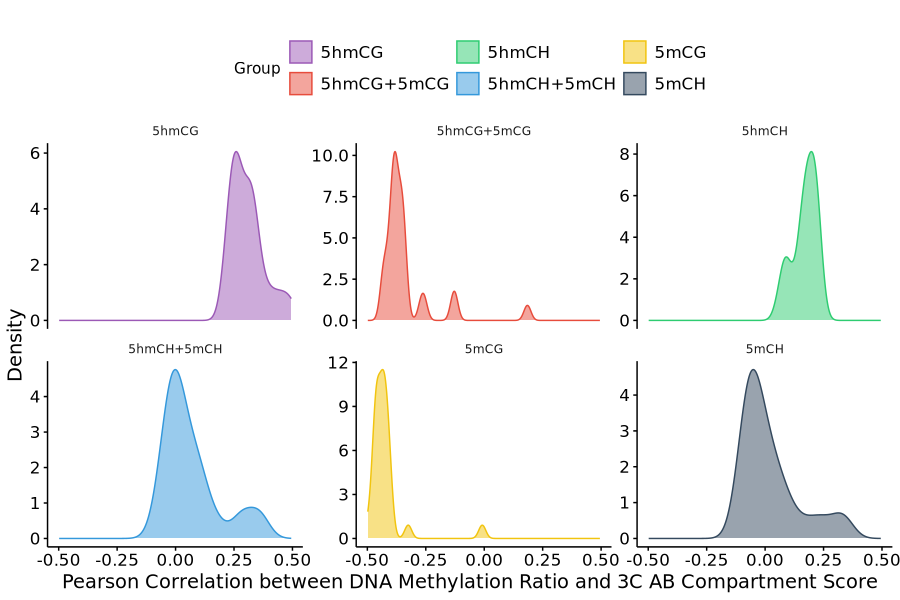

In [53]:
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 100)
ggplot(all_correlations, aes(x = correlation, fill = Group, color = Group)) +
  geom_density(alpha = 0.5) +
  facet_wrap(~ Group, scales = "free_y") +
  theme_minimal() +
  labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
  scale_fill_manual(values = group.col) +
  scale_color_manual(values = group.col) +
  theme(
    legend.position = "top",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )

In [55]:
pic2 <- ggplot(all_correlations, aes(x = correlation, fill = Group, color = Group)) +
  geom_density(alpha = 0.5) +
  facet_wrap(~ Group, scales = "free_y") +
  theme_minimal() +
  labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
  scale_fill_manual(values = group.col) +
  scale_color_manual(values = group.col) +
  theme(
    legend.position = "top",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )

In [ ]:
pdf("../../../output/01-youth/05-AB_compartment/09-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score_split.pdf",width = 9,height = 6)
pic2
dev.off()

png 
  2

In [54]:
all_correlations

subclass,correlation,Group
<chr>,<dbl>,<chr>
L2/3 IT CTX Glut,0.2224626,5hmCG
L4/5 IT CTX Glut,0.2547224,5hmCG
L5 IT CTX Glut,0.2736434,5hmCG
L2/3 IT RSP Glut,0.2642071,5hmCG
L4 RSP-ACA Glut,0.2194816,5hmCG
L5 ET CTX Glut,0.2271405,5hmCG
SUB-ProS Glut,0.2415762,5hmCG
CA1-ProS Glut,0.2370252,5hmCG
CA3 Glut,0.3139932,5hmCG


In [54]:
unique(all_correlations$Group)

[1] "5hmCG"      "5hmCG+5mCG" "5mCG"       "5hmCH"      "5hmCH+5mCH"
[6] "5mCH"

In [55]:
levels(all_correlations$Group)

NULL

In [56]:
all_correlations$Group <- factor(all_correlations$Group,
                                 levels = c("5mCH","5hmCH+5mCH","5hmCH","5mCG","5hmCG+5mCG","5hmCG"))

In [57]:
levels(all_correlations$Group)

[1] "5mCH"       "5hmCH+5mCH" "5hmCH"      "5mCG"       "5hmCG+5mCG"
[6] "5hmCG"

In [58]:
library(ggridges)

Warning message:
“package ‘ggridges’ was built under R version 4.3.2”


In [59]:
pic3 <- ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
geom_density_ridges2(alpha = 0.6) +
scale_fill_manual(values = group.col) +
theme_classic() +
labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
theme(
    legend.position = "right",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )

Picking joint bandwidth of 0.0278



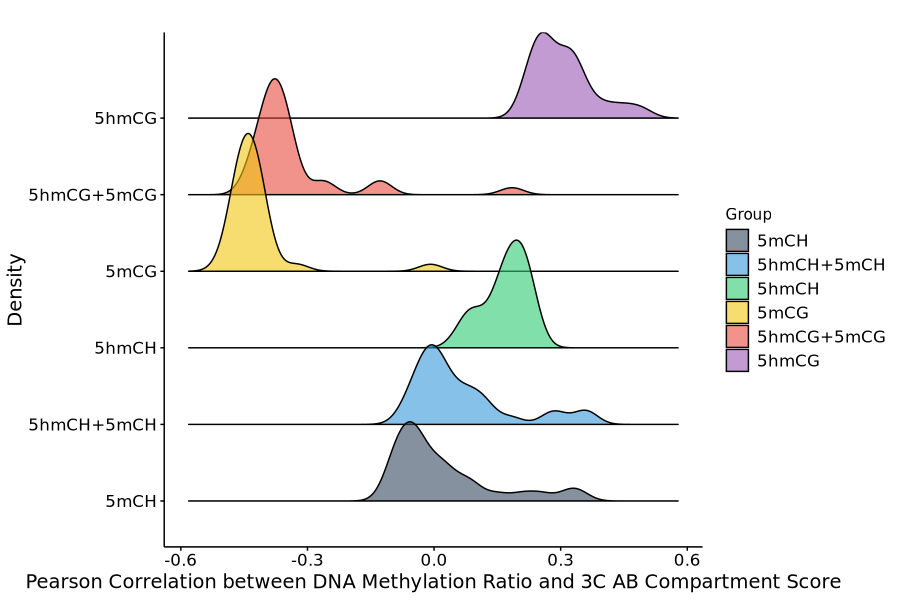

In [60]:
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 100)
pic3

Picking joint bandwidth of 0.0278



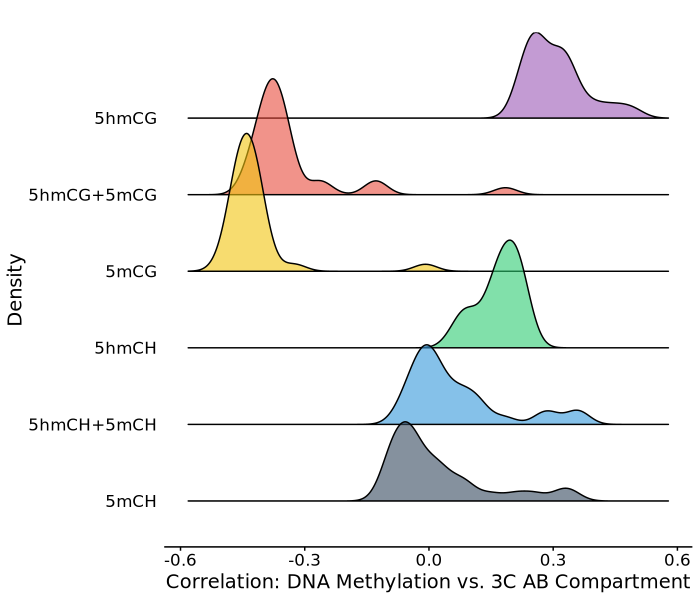

In [68]:
options(repr.plot.width = 7, repr.plot.height = 6, repr.plot.res = 100)
ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
  geom_density_ridges2(alpha = 0.6) +
  scale_fill_manual(values = group.col) +
  theme_classic() +
  labs(
    title = "",
    x = "Correlation: DNA Methylation vs. 3C AB Compartment",
    y = "Density"
  ) +
  theme(
    legend.position = "none",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line.x = element_line(color = "black", size = 0.5),
    axis.line.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.ticks.x = element_line(color = "black")
  )

Picking joint bandwidth of 0.0278



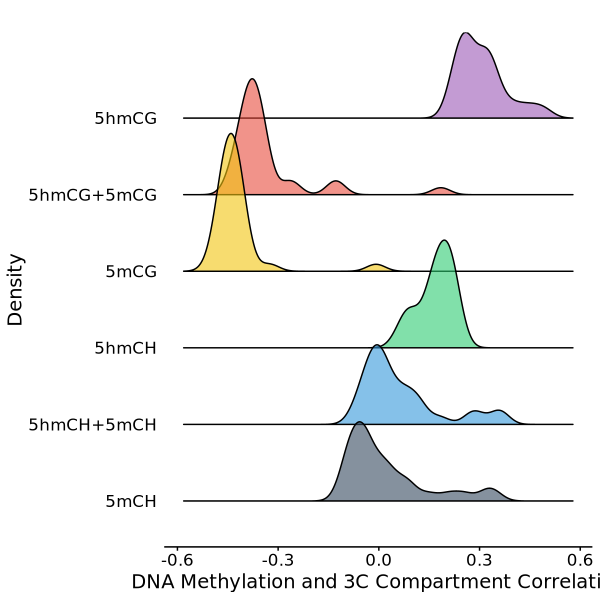

In [71]:
options(repr.plot.width = 6, repr.plot.height = 6, repr.plot.res = 100)
ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
  geom_density_ridges2(alpha = 0.6) +
  scale_fill_manual(values = group.col) +
  theme_classic() +
  labs(
    title = "",
    x = "DNA Methylation and 3C Compartment Correlation",
    y = "Density"
  ) +
  theme(
    legend.position = "none",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line.x = element_line(color = "black", size = 0.5),
    axis.line.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.ticks.x = element_line(color = "black")
  )

In [ ]:
pdf(paste0(outdir,"/09-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score_density_ridges_20241211.pdf"),width = 6,height = 6)
ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
  geom_density_ridges2(alpha = 0.6) +
  scale_fill_manual(values = group.col) +
  theme_classic() +
  labs(
    title = "",
    x = "DNA Methylation and 3C Compartment Correlation",
    y = "Density"
  ) +
  theme(
    legend.position = "none",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line.x = element_line(color = "black", size = 0.5),
    axis.line.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.ticks.x = element_line(color = "black")
  )
dev.off()

Picking joint bandwidth of 0.0278



png 
  2

In [ ]:
pdf("../../../output/01-youth/05-AB_compartment/09-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score_density_ridges.pdf",width = 9,height = 6)
pic3
dev.off()

Picking joint bandwidth of 0.0278



png 
  2

Picking joint bandwidth of 0.0278



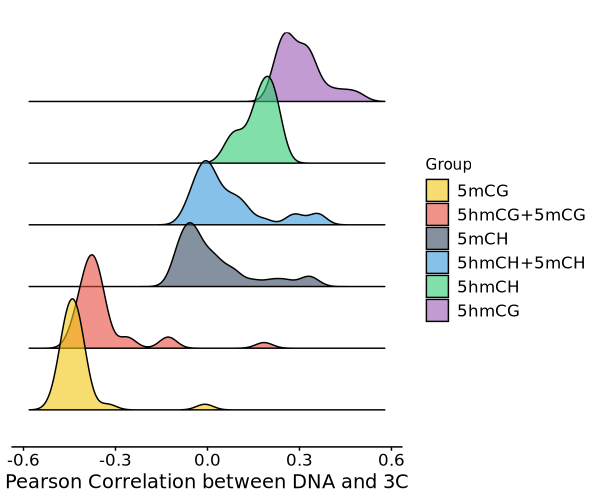

In [69]:
options(repr.plot.width = 6, repr.plot.height = 5, repr.plot.res = 100)
ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
  geom_density_ridges2(alpha = 0.6) +
  scale_fill_manual(values = group.col) +
  theme_classic() +
  labs(
    title = "",
    x = "Pearson Correlation between DNA and 3C",
    y = "Density"
  ) +
  theme(
    legend.position = "right",
    axis.title.x = element_text(color = "black", size = 14),
    axis.title.y = element_blank(),
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.line.y = element_blank(),
    axis.text.x = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line.x = element_line(color = "black", size = 0.5),
    axis.ticks.x = element_line(color = "black")
  )

In [71]:
all_correlations_filtered <- all_correlations %>%
  filter(Group %in% c('5hmCG', '5hmCG+5mCG', '5mCG', '5hmCH', '5hmCH+5mCH', '5mCH')) %>%
  mutate(PlotGroup = ifelse(Group %in% c('5hmCG', '5hmCG+5mCG', '5mCG'), 'CG', 'CH'))

all_correlations_filtered

subclass,correlation,Group,PlotGroup
<chr>,<dbl>,<fct>,<chr>
L2/3 IT CTX Glut,0.2224626,5hmCG,CG
L4/5 IT CTX Glut,0.2547224,5hmCG,CG
L5 IT CTX Glut,0.2736434,5hmCG,CG
L2/3 IT RSP Glut,0.2642071,5hmCG,CG
L4 RSP-ACA Glut,0.2194816,5hmCG,CG
L5 ET CTX Glut,0.2271405,5hmCG,CG
SUB-ProS Glut,0.2415762,5hmCG,CG
CA1-ProS Glut,0.2370252,5hmCG,CG
CA3 Glut,0.3139932,5hmCG,CG


Picking joint bandwidth of 0.0195

Picking joint bandwidth of 0.0361



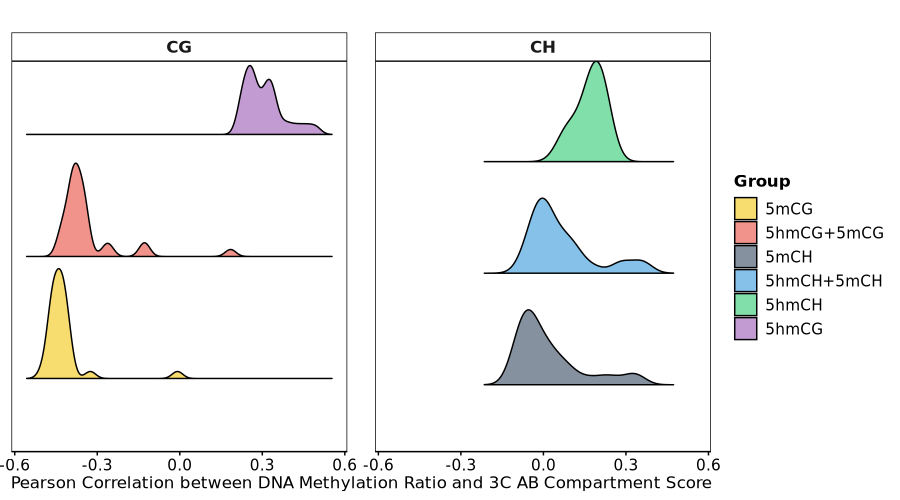

In [140]:
options(repr.plot.width = 9, repr.plot.height = 5, repr.plot.res = 100)
ggplot(data = all_correlations_filtered, 
       aes(x = correlation, y = Group, fill = Group)) +
  geom_density_ridges2(alpha = 0.6, scale = 0.9) +
  scale_fill_manual(values = group.col) +
  theme_classic() +
  labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = NULL,
    fill = "Group"
  ) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 12, face = "bold"),
    legend.text = element_text(size = 11),
    axis.title.x = element_text(size = 12),
    axis.text.x = element_text(size = 11, colour = "black"),
    axis.title.y = element_blank(),
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.line.y = element_blank(),
    axis.line.x = element_line(color = "black", size = 0.5),
    axis.ticks.x = element_line(color = "black", size = 0.5),
    panel.border = element_rect(color = "black", fill = NA, size = 0.5),
    strip.background = element_rect(color = "black", fill = NA, size = 0.5),
    strip.text = element_text(size = 12, face = "bold")
  ) +
  facet_wrap(~PlotGroup, scales = "free_y", ncol = 2) +
  theme(panel.spacing = unit(1.2, "lines"))

In [141]:
pic4 <- ggplot(data = all_correlations_filtered, 
       aes(x = correlation, y = Group, fill = Group)) +
  geom_density_ridges2(alpha = 0.6, scale = 0.9) +
  scale_fill_manual(values = group.col) +
  theme_classic() +
  labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = NULL,
    fill = "Group"
  ) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 12, face = "bold"),
    legend.text = element_text(size = 11),
    axis.title.x = element_text(size = 12),
    axis.text.x = element_text(size = 11, colour = "black"),
    axis.title.y = element_blank(),
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.line.y = element_blank(),
    axis.line.x = element_line(color = "black", size = 0.5),
    axis.ticks.x = element_line(color = "black", size = 0.5),
    panel.border = element_rect(color = "black", fill = NA, size = 0.5),
    strip.background = element_rect(color = "black", fill = NA, size = 0.5),
    strip.text = element_text(size = 12, face = "bold")
  ) +
  facet_wrap(~PlotGroup, scales = "free_y", ncol = 2) +
  theme(panel.spacing = unit(1.2, "lines"))

Picking joint bandwidth of 0.0195

Picking joint bandwidth of 0.0361



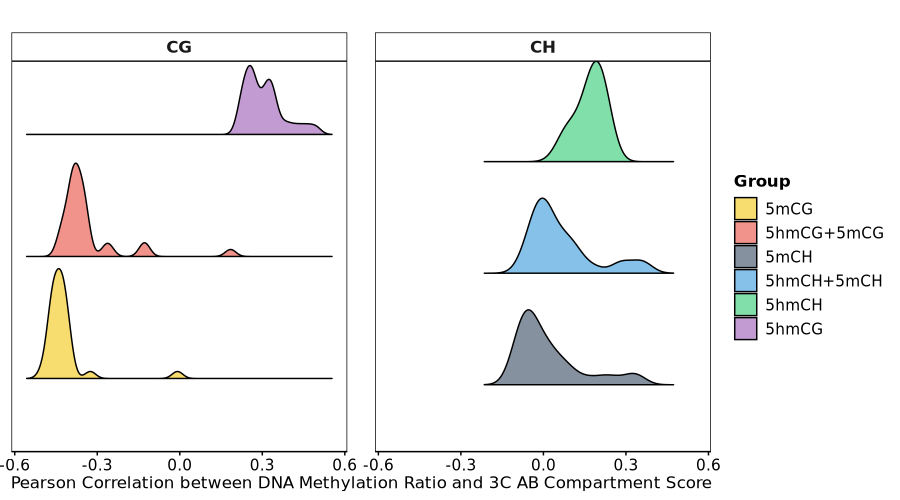

In [142]:
options(repr.plot.width = 9, repr.plot.height = 5, repr.plot.res = 100)
pic4

In [ ]:
pdf(paste0(outdir,"/09-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score_density_ridges_split.pdf"),width = 9,height = 5)
pic4
dev.off()

Picking joint bandwidth of 0.0195

Picking joint bandwidth of 0.0361



png 
  2